# <center>Olist Brazilian E-commerce Business Analytics</center>

**EXECUTIVE SUMMARY**

- The rapid growth of e-commerce has generated large volumes of transactional, customer, logistics, and payment data. 
- Transforming this data into actionable insights is essential for improving operational efficiency, enhancing customer satisfaction, and driving revenue growth. This project performs a comprehensive business analysis of the Olist Brazilian E-commerce dataset by integrating multiple relational datasets into a unified analytical model.

- Using Python and its data analysis ecosystem, the project covers the complete analytics lifecycle, including data cleaning, feature engineering, exploratory data analysis, customer segmentation, logistics analysis, payment analysis, and business performance evaluation. 
- Key analytical techniques such as RFM Segmentation, Pareto Analysis (80/20 Rule), and Correlation Analysis were applied to uncover customer behavior, revenue drivers, and operational bottlenecks.

- The analysis identifies sales trends, high-value customers, top-performing products and sellers, preferred payment methods, customer satisfaction patterns, regional business performance, and delivery efficiency. 
- Based on these findings, practical business recommendations are proposed to support strategic decision-making and improve overall business performance.

- This project demonstrates an end-to-end business analytics workflow using Python, showcasing skills in data preparation, visualization, statistical analysis, and business storytelling.

**BUSINESS PROBLEM STATEMENT**

- Modern e-commerce businesses generate vast amounts of transactional, customer, payment, product, seller, and logistics data every day. 
- While this data contains valuable business intelligence, organizations often struggle to convert it into actionable insights that support strategic decision-making.

- Business leaders require a comprehensive understanding of sales performance, customer purchasing behavior, product demand, seller performance, payment preferences, customer satisfaction, and delivery efficiency to optimize operations and maximize profitability. 
- Without a unified analytical approach, identifying revenue opportunities, operational bottlenecks, and customer retention strategies becomes challenging.

- This project addresses these challenges by integrating multiple relational datasets from the Olist Brazilian E-commerce platform into a single analytical model. 
- Through data cleaning, feature engineering, exploratory data analysis, customer segmentation, and business performance evaluation, the project aims to uncover meaningful insights and provide data-driven recommendations for improving overall business performance.

**BUSINESS OBJECTIVES**

The primary objectives of this project are to:

1. Analyze overall sales performance and identify monthly revenue and order trends.

2. Evaluate customer purchasing behavior and identify high-value customers using RFM segmentation.

3. Identify top-performing products and sellers based on sales volume and revenue contribution.

4. Analyze payment methods and installment preferences to understand customer payment behavior.

5. Evaluate customer satisfaction through review scores and identify factors influencing ratings.

6. Assess delivery performance across different regions and identify logistics inefficiencies.

7. Compare business performance across states and cities to identify high-performing markets.

8. Apply Pareto Analysis to determine the proportion of customers contributing to overall revenue.

9. Examine relationships between delivery time, customer ratings, payment value, and purchasing behavior using correlation analysis.

10. Generate actionable business insights and strategic recommendations to support data-driven decision-making.

**DATASET OVERVIEW**

1. This project uses the Olist Brazilian E-commerce Public Dataset, which contains transactional data from one of Brazil's largest online marketplaces.

2. The dataset captures the complete customer purchasing journey, from order placement and payment to product delivery and customer reviews.

3. The analysis integrates multiple relational datasets to build a unified analytical model, enabling comprehensive business analysis across sales, customers, products, sellers, payments, logistics, and customer satisfaction.

Analysis Tool: Python (Pandas, NumPy, Matplotlib, Seaborn)

**DATASET SUMMARY**

| Dataset             | Description                                      | Records |
|---------------------|--------------------------------------------------|---------|
| Customers           | Customer demographics and location information   | 99,441  |
| Orders              | Order lifecycle and delivery information         | 99,441  |
| Order Items         | Individual products purchased within each order  | 112,650 |
| Payments            | Payment methods, installments, and payment values| 103,886 |
| Products            | Product attributes and categories                | 32,951  |
| Reviews             | Customer ratings and review information          | 99,224  |
| Category Translation| Portuguese to English product category mapping   | 71      |


**KEY BUSINESS ENTITIES**

The analysis is built around seven core business entities:

1. Customers – Customer identity and geographic information.
2. Orders – Purchase transactions and order status.
3. Products – Product catalog and category information.
4. Sellers – Merchants fulfilling customer orders.
5. Payments – Payment methods, installments, and transaction values.
6. Reviews – Customer satisfaction ratings and feedback.
7. Logistics – Order approval, shipping, and delivery timelines.

**ANALYTICAL SCOPE**

The integrated dataset enables analysis across multiple business functions, including:

1. Sales Performance
2. Customer Analytics
3. Product Performance
4. Seller Performance
5. Payment Analysis
6. Customer Satisfaction
7. Geographic Performance
8. Delivery & Logistics
9. Customer Segmentation (RFM)
10. Pareto Analysis
11. Correlation Analysis

**DATA MODEL OVERVIEW**

```mermaid
flowchart TD
    Customers -->|customer_id| Orders
    Orders --> OrderItems
    Orders --> Payments
    OrderItems --> Products
    Products --> CategoryTranslation
    Orders --> Reviews

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
print("setup_successful")

setup_successful


In [3]:
customers = pd.read_csv(r"D:\Python Practice\Project 2\archive\olist_customers_dataset.csv")
orders = pd.read_csv(r"D:\Python Practice\Project 2\archive\olist_orders_dataset.csv")
order_items = pd.read_csv(r"D:\Python Practice\Project 2\archive\olist_order_items_dataset.csv")
payments = pd.read_csv(r"D:\Python Practice\Project 2\archive\olist_order_payments_dataset.csv")
products = pd.read_csv(r"D:\Python Practice\Project 2\archive\olist_products_dataset.csv")
reviews = pd.read_csv(r"D:\Python Practice\Project 2\archive\olist_order_reviews_dataset.csv")
translation = pd.read_csv(r"D:\Python Practice\Project 2\archive\product_category_name_translation.csv")

**DATA SHAPE INVESTIGATION**

In [4]:
print(customers.shape)
print(orders.shape)
print(order_items.shape)
print(payments.shape)
print(products.shape)
print(reviews.shape)
print(translation.shape)

(99441, 5)
(99441, 8)
(112650, 7)
(103886, 5)
(32951, 9)
(99224, 7)
(71, 2)


**DATA QUALITY ASSESSMENT**

In [5]:
customers.head()
customers.info()
customers.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [6]:
orders.head()
orders.info()
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
order_items.head()
order_items.info()
order_items.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [8]:
payments.head()
payments.info()
payments.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [9]:
products.head()
products.info()
products.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [10]:
reviews.head()
reviews.info()
reviews.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [11]:
translation.head()
translation.info()
translation.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


product_category_name            0
product_category_name_english    0
dtype: int64

**UNIQUE KEY ASSESSMENT**

In [12]:
customers['customer_id'].nunique(),len(customers)

(99441, 99441)

In [13]:
orders['order_id'].nunique(),len(orders)

(99441, 99441)

In [14]:
products['product_id'].nunique(), len(products)

(32951, 32951)

In [15]:
reviews['order_id'].nunique(), len(reviews)

(98673, 99224)

**RELATIONSHIP CARDINALITY CHECK**

In [16]:
orders['customer_id'].duplicated().sum()

np.int64(0)

In [17]:
order_items['order_id'].duplicated().sum()

np.int64(13984)

In [18]:
payments['order_id'].duplicated().sum()

np.int64(4446)

In [19]:
reviews['order_id'].duplicated().sum()

np.int64(551)

**KEY FINDINGS - Data model Validation**

*Customers <--> Orders (One-to-One)*

In [20]:
customers['customer_id'].nunique() == len(customers)
orders['customer_id'].duplicated().sum()

np.int64(0)

Finding
- Every customer_id appears exactly once in both tables.
- Each order belongs to one customer.

*Orders <--> Order Items (One-to-Many)*

In [21]:
order_items['order_id'].duplicated().sum()

np.int64(13984)

*Orders <--> Payments (One-to-Many)*

In [22]:
payments['order_id'].duplicated().sum()

np.int64(4446)

Some orders have multiple review records (e.g., review updates or multiple entries).

**DATA CLEANING & FEATURE ENGINEERING**

1. Date to Columns

In [23]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], format="%d-%m-%Y %H:%M", errors="coerce")

In [24]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


2. Date-Time style conversion

In [25]:
orders['purchase_year'] = orders['order_purchase_timestamp'].dt.year
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_month_name'] = orders['order_purchase_timestamp'].dt.month_name()
orders['purchase_day'] = orders['order_purchase_timestamp'].dt.day_name()
orders['purchase_hour'] = orders['order_purchase_timestamp'].dt.hour

In [26]:
orders[['order_purchase_timestamp', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_hour']].head()

,order_purchase_timestamp,purchase_year,purchase_month,purchase_day,purchase_hour
0,2017-10-02 10:56:00,2017,10,Monday,10
1,2018-07-24 20:41:00,2018,7,Tuesday,20
2,2018-08-08 08:38:00,2018,8,Wednesday,8
3,2017-11-18 19:28:00,2017,11,Saturday,19
4,2018-02-13 21:18:00,2018,2,Tuesday,21


3. Delivery Performance Metrics

In [27]:
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

In [28]:
orders['delivery_days']

0         8.0
1        13.0
2         9.0
3        13.0
4         2.0
         ... 
99436     8.0
99437    22.0
99438    24.0
99439    17.0
99440     7.0
Name: delivery_days, Length: 99441, dtype: float64

In [29]:
orders['approval_time_hours'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds()/3600

In [30]:
orders['approval_time_hours']

0         0.183333
1        30.716667
2         0.283333
3         0.283333
4         1.033333
           ...    
99436     0.000000
99437     0.200000
99438     0.300000
99439     0.133333
99440    14.383333
Name: approval_time_hours, Length: 99441, dtype: float64

In [31]:
orders['estimated_delivery_gap'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

In [32]:
orders['estimated_delivery_gap']

0        -8.0
1        -6.0
2       -18.0
3       -13.0
4       -10.0
         ... 
99436   -11.0
99437    -2.0
99438    -6.0
99439   -21.0
99440   -18.0
Name: estimated_delivery_gap, Length: 99441, dtype: float64

4. Column Inspection

In [33]:
orders[['delivery_days', 'approval_time_hours', 'estimated_delivery_gap']]

,delivery_days,approval_time_hours,estimated_delivery_gap
0,8.0,0.183333,-8.0
1,13.0,30.716667,-6.0
2,9.0,0.283333,-18.0
3,13.0,0.283333,-13.0
4,2.0,1.033333,-10.0
...,...,...,...
99436,8.0,0.000000,-11.0
99437,22.0,0.200000,-2.0
99438,24.0,0.300000,-6.0
99439,17.0,0.133333,-21.0


# 1. MASTER DATASET CREATION

Orders Master Dataframe

In [34]:
payments_agg = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        total_payment=("payment_value", "sum"),
        total_installments=("payment_installments", "max"),
        payment_type=("payment_type", lambda x: ", ".join(sorted(x.unique())))
    )
)

In [35]:
payments_agg.head()

,order_id,total_payment,total_installments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


In [36]:
payments_agg.shape

(99440, 4)

In [37]:
reviews_agg = (
    reviews
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean")
    )
)

In [38]:
orders_master = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_agg, on="order_id", how="left")
)

In [39]:
orders_master.shape

(99441, 24)

In [40]:
orders_master["order_id"].nunique()

99441

In [41]:
len(orders_master)

99441

In [42]:
orders_master["order_id"].nunique() == len(orders_master)

True

In [43]:
payments["payment_value"].sum()

np.float64(16008872.120000001)

In [44]:
orders_master["total_payment"].sum()

np.float64(16008872.120000001)

8.Items Master Dataframe

In [45]:
items_master = (
    order_items
    .merge(products, on="product_id", how="left")
    .merge(translation, on="product_category_name", how="left")
    .merge(
        orders[
            [
                "order_id",
                "customer_id",
                "purchase_year",
                "purchase_month",
                "purchase_month_name",
                "purchase_day",
                "purchase_hour",
                "delivery_days",
                "estimated_delivery_gap",
                "order_status"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        customers[
            [
                "customer_id",
                "customer_unique_id",
                "customer_state",
                "customer_city"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

In [46]:
items_master.shape

(112650, 28)

In [47]:
items_master["order_item_id"].count()

np.int64(112650)

In [48]:
order_items["order_id"].nunique()

98666

In [49]:
items_master["order_id"].nunique()

98666

# 2.KEY PERFORMANCE INDICATORS 

1. Total Revenue

In [50]:
total_revenue = orders_master['total_payment'].sum()
print(f"Total Revenue: {total_revenue:,.0f}")

Total Revenue: 16,008,872


2. Total Orders

In [51]:
total_orders = orders_master['order_id'].nunique()
print(f"Total Orders: {total_orders:,}")

Total Orders: 99,441


3. Total Customers

In [52]:
total_customers = orders_master['customer_unique_id'].nunique()
print(f"Total Customers: {total_customers:,}")

Total Customers: 96,096


4. Total Products Sold

In [53]:
total_products_sold = items_master['order_item_id'].count()

print(f"Total Products: {total_products_sold:,}")

Total Products: 112,650


5. Average Order Value (AOV)

In [54]:
average_order_value = orders_master['total_payment'].mean()
print(f"Average Order Value: {average_order_value:,.2f}")

Average Order Value: 160.99


6. Average Delivery Time

In [55]:
avg_delivery_time = orders_master['delivery_days'].mean()
print(f"Average Delivery Time: {avg_delivery_time:.0f}days")

Average Delivery Time: 12days


7. Average Review Score

In [56]:
avg_review_score = orders_master['review_score'].mean()
print(f"Average Review Score: {avg_review_score:.2f}/5")

Average Review Score: 4.09/5


9. Total Sellers

In [57]:
total_sellers = items_master['seller_id'].nunique()
total_sellers

3095

10. Executive Summary

In [58]:
executive_kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products Sold",
        "Total Sellers",
        "Average Order Value",
        "Average Delivery Time (Days)",
        "Average Review Score"
    ],
    "Value": [
        f"₹{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{total_products_sold:,}",
        f"{total_sellers:,}",
        f"₹{average_order_value:,.2f}",
        f"{avg_delivery_time:.2f}",
        f"{avg_review_score:.2f}/5"
    ]
})

In [59]:
executive_kpi

,Metric,Value
0,Total Revenue,"₹16,008,872.12"
1,Total Orders,"99,441"
2,Total Customers,"96,096"
3,Total Products Sold,"112,650"
4,Total Sellers,"3,095"
5,Average Order Value,₹160.99
6,Average Delivery Time (Days),12.09
7,Average Review Score,4.09/5


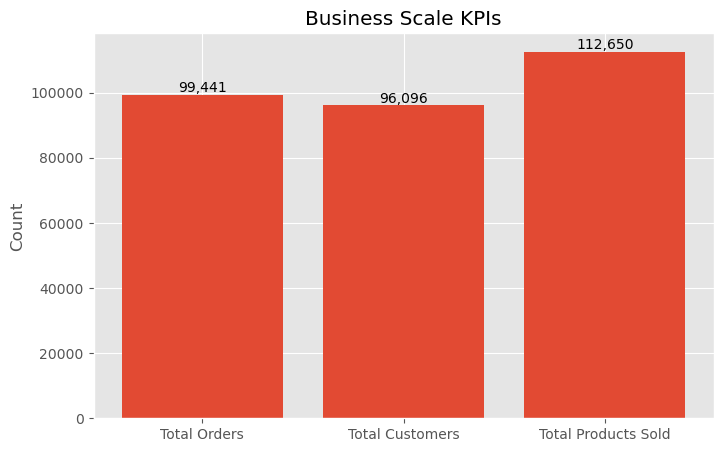

In [60]:
kpi_counts = pd.DataFrame({'Metric': ['Total Orders','Total Customers','Total Products Sold'],
                              'Value' :[total_orders,total_customers,total_products_sold]})

plt.figure(figsize=(8,5))

bars = plt.bar(kpi_counts['Metric'], kpi_counts['Value'])
plt.title("Business Scale KPIs")
plt.ylabel("Count")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, height, f"{height:,.0f}", ha = 'center', va = 'bottom')

plt.show()

# 3.SALES PERFORMANCE ANALYSIS

1. MONTHLY REVENUE TREND

In [61]:
monthly_revenue = orders_master.groupby(['purchase_year', 'purchase_month', 'purchase_month_name'])['total_payment'].sum().reset_index()
monthly_revenue

,purchase_year,purchase_month,purchase_month_name,total_payment
0,2016,9,September,252.24
1,2016,10,October,59090.48
2,2016,12,December,19.62
3,2017,1,January,138488.04
4,2017,2,February,291908.01
5,2017,3,March,449863.60
6,2017,4,April,417788.03
7,2017,5,May,592918.82
8,2017,6,June,511276.38
9,2017,7,July,592382.92


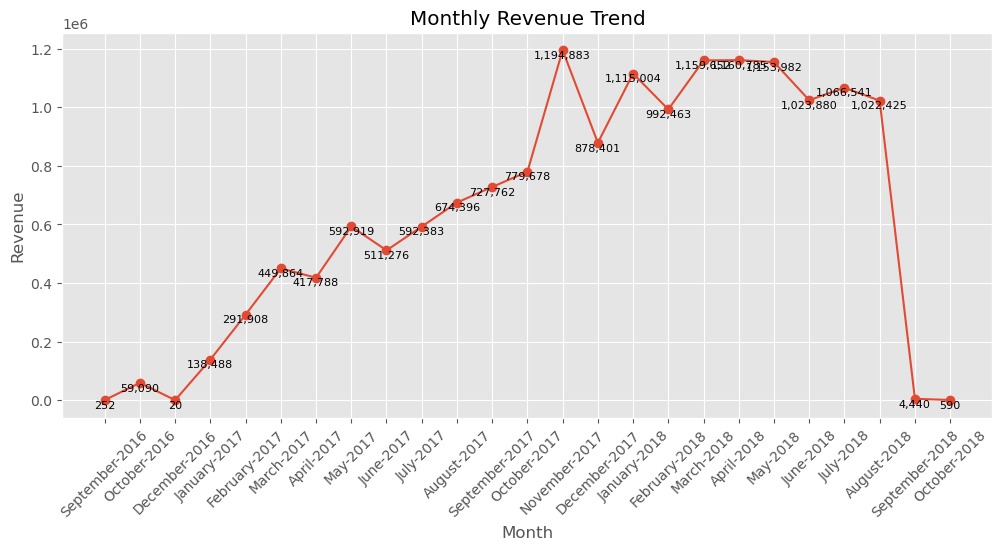

In [62]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue['purchase_month_name'] + "-" +
    monthly_revenue['purchase_year'].astype(str),
    monthly_revenue['total_payment'],
    marker='o'
)

# Add data labels
for x, y in zip(
    monthly_revenue['purchase_month_name'] + "-" +
    monthly_revenue['purchase_year'].astype(str),
    monthly_revenue['total_payment']
):
    plt.text(
        x,
        y,
        f'{y:,.0f}',
        ha='center',
        va='top',
        fontsize=8
    )

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

2. MONTHLY ORDERS

In [63]:
monthly_orders = (
    orders_master
    .groupby(
        ['purchase_year', 'purchase_month', 'purchase_month_name']
    )['order_id']
    .nunique()
    .reset_index(name='monthly_orders')
    .sort_values(['purchase_year', 'purchase_month'])
)

monthly_orders.head()

,purchase_year,purchase_month,purchase_month_name,monthly_orders
0,2016,9,September,4
1,2016,10,October,324
2,2016,12,December,1
3,2017,1,January,800
4,2017,2,February,1780


In [64]:
monthly_orders['purchase_month_name'] = pd.to_datetime(
    monthly_orders['purchase_month'],
    format='%m'
).dt.month_name()

In [65]:
monthly_orders['purchase_month_name'] = pd.to_datetime(
    monthly_orders['purchase_month'],
    format='%m'
).dt.month_name()

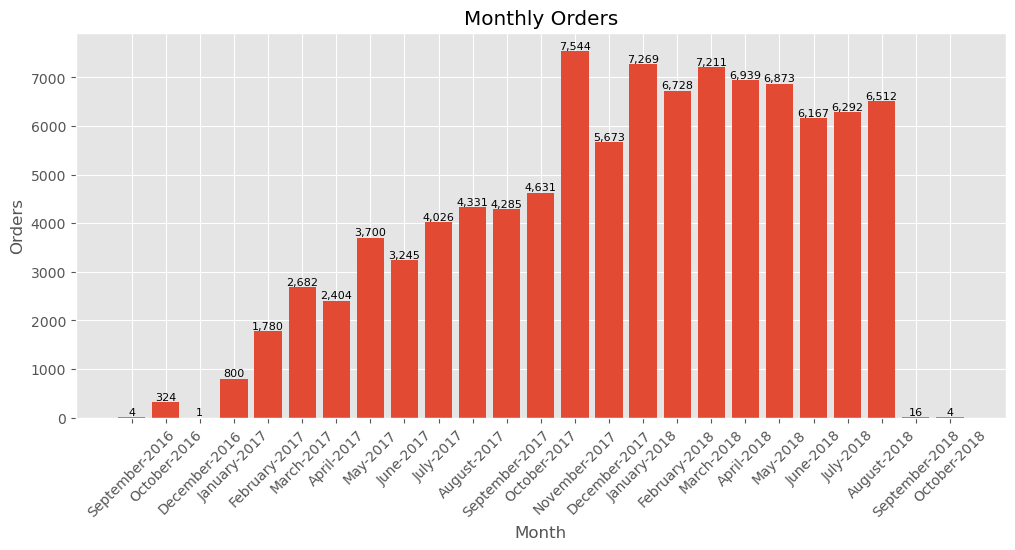

In [66]:
plt.figure(figsize=(12,5))

bars = plt.bar(
    monthly_orders['purchase_month_name'] + "-" + 
    monthly_orders['purchase_year'].astype(str), 
    monthly_orders['monthly_orders'])
plt.xticks(rotation = 45)
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Orders")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{int(bar.get_height()):,}", ha = 'center', va = 'bottom', fontsize = 8)

plt.show()

3. MONTHLY REVENUE GROWTH %

In [67]:
growth_df = monthly_revenue.iloc[3:].copy()

In [68]:
growth_df = growth_df[((growth_df['purchase_year'] == 2017) & (growth_df['purchase_month'] >= 1)) |
                      ((growth_df['purchase_year'] == 2018) & (growth_df['purchase_month'] <= 8))].copy()
                      

In [69]:
growth_df['growth %'] = (
    growth_df['total_payment']
    .pct_change() * 100
)

In [70]:
growth_df['growth %']

3            NaN
4     110.782108
5      54.111427
6      -7.130066
7      41.918575
8     -13.769581
9      15.863541
10     13.844660
11      7.913170
12      7.133568
13     53.253392
14    -26.486390
15     26.935599
16    -10.990169
17     16.845839
18      0.097733
19     -0.586097
20    -11.274148
21      4.166526
22     -4.136310
Name: growth %, dtype: float64

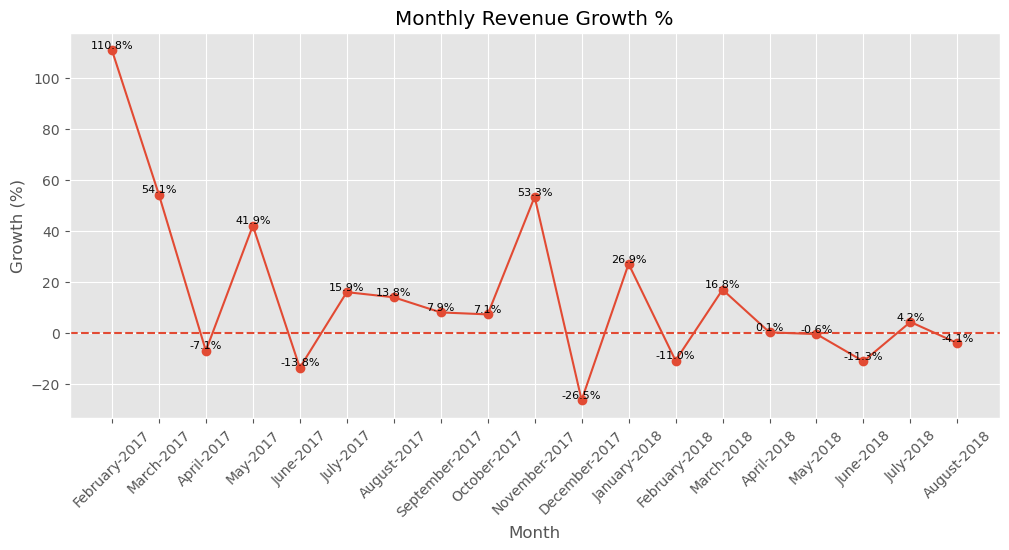

In [71]:
plt.figure(figsize=(12,5))

plt.plot(
    growth_df['purchase_month_name'] + "-" +
    growth_df['purchase_year'].astype(str),
    growth_df['growth %'],
    marker='o'
)

for x, y in zip(
    growth_df['purchase_month_name'] + "-" +
    growth_df['purchase_year'].astype(str),
    growth_df['growth %']
):
    if pd.notna(y):
        plt.text(
            x,
            y,
            f'{y:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.axhline(0, linestyle='--')

plt.xticks(rotation=45)

plt.title("Monthly Revenue Growth %")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.show()

4. BEST SALES MONTH

In [72]:
best_month = monthly_revenue.loc[monthly_revenue['total_payment'].idxmax()]
print(best_month)

purchase_year               2017
purchase_month                11
purchase_month_name     November
total_payment          1194882.8
Name: 13, dtype: object


5. HIGHEST ORDER MONTH

In [73]:
highest_order_month = monthly_orders.loc[monthly_orders['monthly_orders'].idxmax()]
print(highest_order_month)

purchase_year              2017
purchase_month               11
purchase_month_name    November
monthly_orders             7544
Name: 13, dtype: object


# 4.CUSTOMER ANALYTICS

1) CUSTOMER KPI's

In [74]:
# Total Customers
total_customers = orders_master['customer_unique_id'].nunique()

# Total Orders
total_orders = orders_master['order_id'].nunique()

# Repeat Customers
repeat_customers = (orders_master.groupby('customer_unique_id')['order_id'].nunique())
repeat_customers = (repeat_customers > 1).sum()

# Repeat Customer Rate
repeat_customer_rate = round((repeat_customers/total_customers) * 100,2)

#Average Order Per Customer
avg_order_per_customer = round(total_orders / total_customers,0)

In [75]:
total_customers

96096

In [76]:
total_orders

99441

In [77]:
repeat_customers

np.int64(2997)

In [78]:
repeat_customer_rate

np.float64(3.12)

In [79]:
avg_order_per_customer

1.0

In [80]:
# Customer KPI's 
customer_kpi = pd.DataFrame({'Metric': ['Total Customers', 'Total Orders', 'Repeat Customers', 'Repeat Customer Rate (%)', 'Average Order per Customer'],
                             'Value' : [total_customers,total_orders, repeat_customers,repeat_customer_rate,avg_order_per_customer]})

In [81]:
customer_kpi

,Metric,Value
0,Total Customers,96096.00
1,Total Orders,99441.00
2,Repeat Customers,2997.00
3,Repeat Customer Rate (%),3.12
4,Average Order per Customer,1.00


2) CUSTOMER PURCHASE FREQUENCY

In [82]:
customer_orders = orders_master.groupby('customer_unique_id')['order_id'].nunique().reset_index(name='orders')
customer_orders.head()

,customer_unique_id,orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


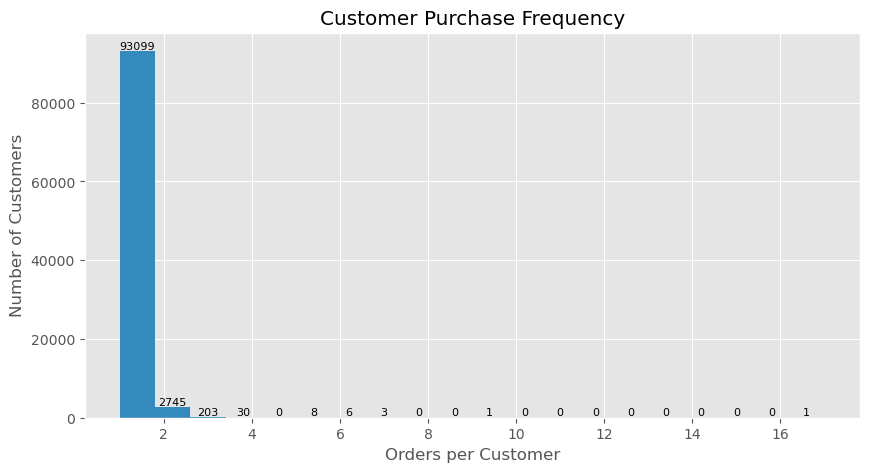

In [83]:
plt.figure(figsize=(10,5))

plt.hist(customer_orders['orders'], bins=20)

counts, bins, patches = plt.hist(customer_orders['orders'], bins=20)

plt.title("Customer Purchase Frequency")
plt.xlabel("Orders per Customer")
plt.ylabel("Number of Customers")

for count, patch in zip(counts, patches):
    # Get the bar's x and y position
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    plt.text(x, y, str(int(count)), ha='center', va='bottom', fontsize=8)

plt.show()

3) TOP CUSTOMERS BY ORDERS

In [84]:
top_customers_by_orders = customer_orders.sort_values('orders', ascending=False)

In [85]:
top_customers_by_orders.head(10)

,customer_unique_id,orders
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
23472,3e43e6105506432c953e165fb2acf44c,9
37797,6469f99c1f9dfae7733b25662e7f1782,7
76082,ca77025e7201e3b30c44b472ff346268,7
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,6
83540,de34b16117594161a6a89c50b289d35a,6
37585,63cfc61cee11cbe306bff5857d00bfe4,6
90451,f0e310a6839dce9de1638e0fe5ab282a,6
27043,47c1a3033b8b77b3ab6e109eb4d5fdf3,6


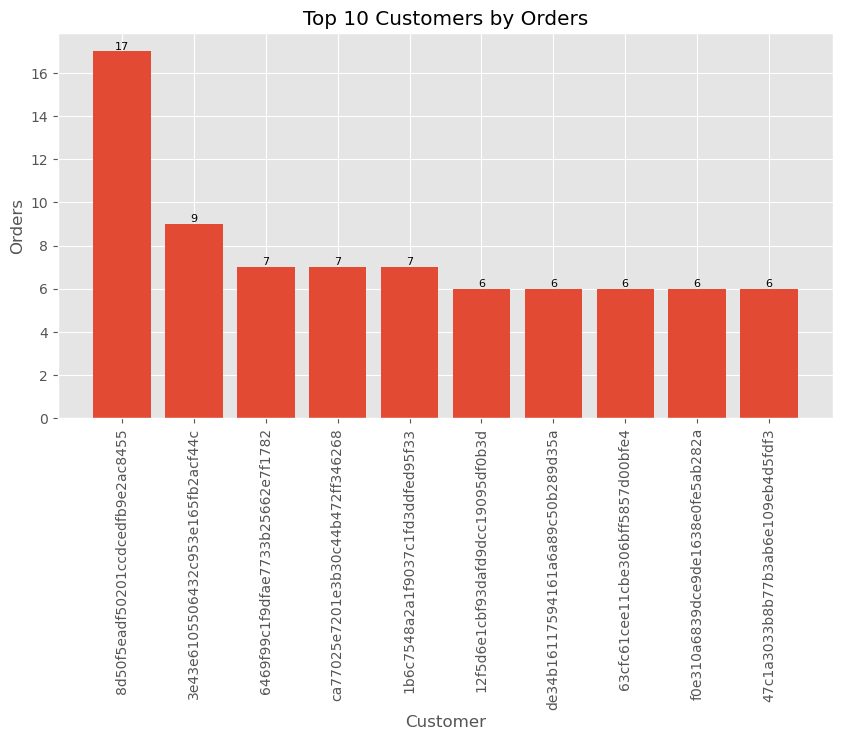

In [86]:
top_customers_by_orders = customer_orders.sort_values('orders', ascending=False).head(10)

plt.figure(figsize=(10,5))

bars = plt.bar(
    top_customers_by_orders['customer_unique_id'],
    top_customers_by_orders['orders']
)

plt.xticks(rotation=90)
plt.title("Top 10 Customers by Orders")
plt.xlabel("Customer")
plt.ylabel("Orders")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.show()

4) TOP CUSTOMERS BY REVENUE

In [87]:
top_customers_by_revenue = (orders_master.groupby('customer_unique_id')['total_payment'].sum().reset_index())

In [88]:
top_customers_by_revenue.shape

(96096, 2)

In [89]:
top_customers_by_revenue = top_customers_by_revenue.rename(columns = {'total_payment':'revenue'})
top_customers_by_revenue


,customer_unique_id,revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89
...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,2067.42
96092,fffea47cd6d3cc0a88bd621562a9d061,84.58
96093,ffff371b4d645b6ecea244b27531430a,112.46
96094,ffff5962728ec6157033ef9805bacc48,133.69


In [90]:
top_10_customers = top_customers_by_revenue.head(10)
top_10_customers

,customer_unique_id,revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89
5,0004bd2a26a76fe21f786e4fbd80607f,166.98
6,00050ab1314c0e55a6ca13cf7181fecf,35.38
7,00053a61a98854899e70ed204dd4bafe,419.18
8,0005e1862207bf6ccc02e4228effd9a0,150.12
9,0005ef4cd20d2893f0d9fbd94d3c0d97,129.76


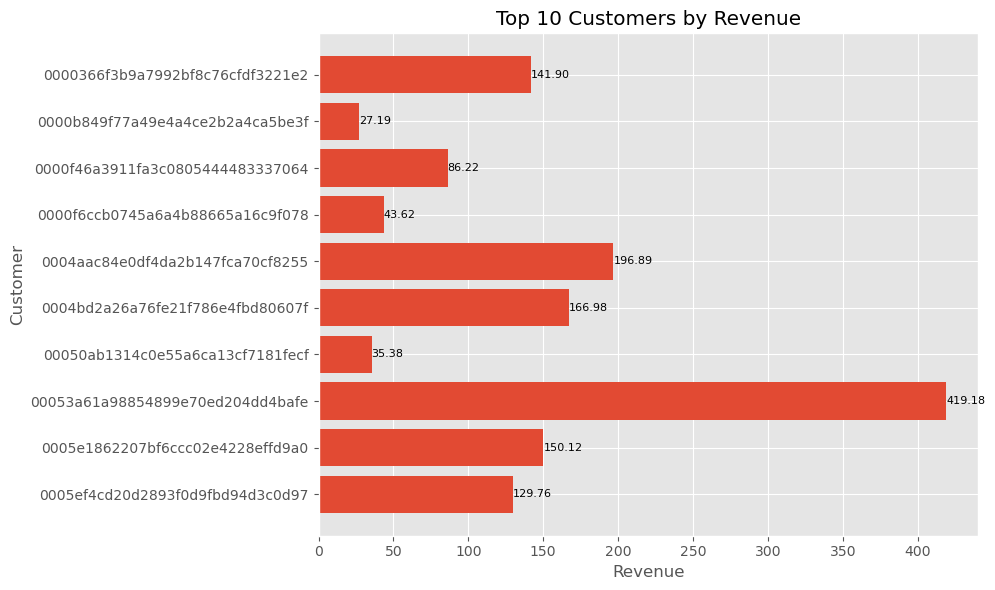

In [91]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    top_10_customers['customer_unique_id'],
    top_10_customers['revenue']
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.2f}",
        va='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()

5) KEY PERFORMANCE INDICATORS

In [92]:
print("Highest Customer Revenue:", top_10_customers['revenue'].max())
print("Average Revenue of Top 10 Customers :", round(top_10_customers['revenue'].mean(),2))

Highest Customer Revenue: 419.18
Average Revenue of Top 10 Customers : 139.72


# 5.CUSTOMER PURCHASE FREQUENCY ANALYSIS

1) ORDERS PER CUSTOMERS

In [93]:
orders_per_customer = (
    orders_master
    .groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index(name='total_orders')
)

orders_per_customer.head(10)

,customer_unique_id,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
5,0004bd2a26a76fe21f786e4fbd80607f,1
6,00050ab1314c0e55a6ca13cf7181fecf,1
7,00053a61a98854899e70ed204dd4bafe,1
8,0005e1862207bf6ccc02e4228effd9a0,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1


2) CUSTOMER CLASSIFICATION

In [94]:
orders_per_customer['customer_type'] = np.where(orders_per_customer['total_orders'] == 1, 'one-time customer','repeat_customer')
orders_per_customer.head()

,customer_unique_id,total_orders,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,one-time customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,one-time customer
2,0000f46a3911fa3c0805444483337064,1,one-time customer
3,0000f6ccb0745a6a4b88665a16c9f078,1,one-time customer
4,0004aac84e0df4da2b147fca70cf8255,1,one-time customer


3) CUSTOMER SUMMARY

In [95]:
customer_summary = (orders_per_customer.groupby('customer_type').size().reset_index(name='customers'))
customer_summary

,customer_type,customers
0,one-time customer,93099
1,repeat_customer,2997


4) PERCENTAGE

In [96]:
customer_summary['percentage'] = (customer_summary['customers'] / customer_summary['customers'].sum())
customer_summary

,customer_type,customers,percentage
0,one-time customer,93099,0.968812
1,repeat_customer,2997,0.031188


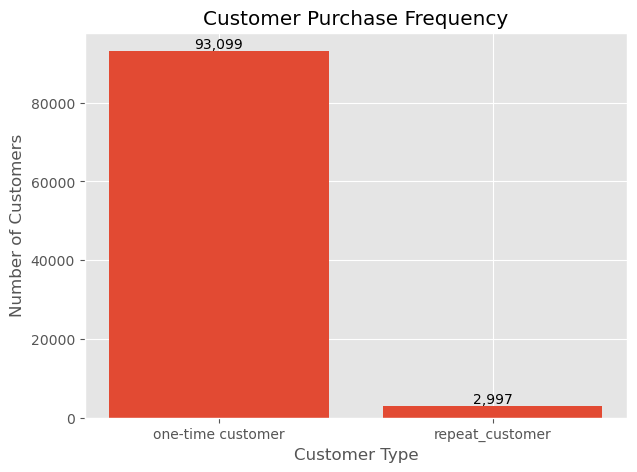

In [97]:
plt.figure(figsize=(7,5))

bars = plt.bar(customer_summary['customer_type'], customer_summary['customers'])
plt.title("Customer Purchase Frequency")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{int(bar.get_height()):,}", ha = 'center', va = 'bottom')

plt.show()

5) KEY PERFORMANCE INDICATOR

In [98]:
repeat_rate = (customer_summary.loc[customer_summary['customer_type'] == 'repeat_customer', 'percentage'].iloc[0])
print(f"Repeat Customer Rate : {repeat_rate:.2f}%")

Repeat Customer Rate : 0.03%


# 6.CUSTOMER LIFETIME VALUE (CUSTOMER REVENUE DISTRIBUTION)

1) CUSTOMER LIFETIME VALUE

In [99]:
customer_lifetime_value = (
    orders_master
    .groupby('customer_unique_id')['total_payment']
    .sum()
    .reset_index(name='customer_revenue')
)

customer_lifetime_value.head()

,customer_unique_id,customer_revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


2) SUMMARY STATISTICS

In [100]:
customer_lifetime_value['customer_revenue'].describe()

count    96096.000000
mean       166.592492
std        231.428332
min          0.000000
25%         63.120000
50%        108.000000
75%        183.530000
max      13664.080000
Name: customer_revenue, dtype: float64

3) DISTRIBUTION PLOT

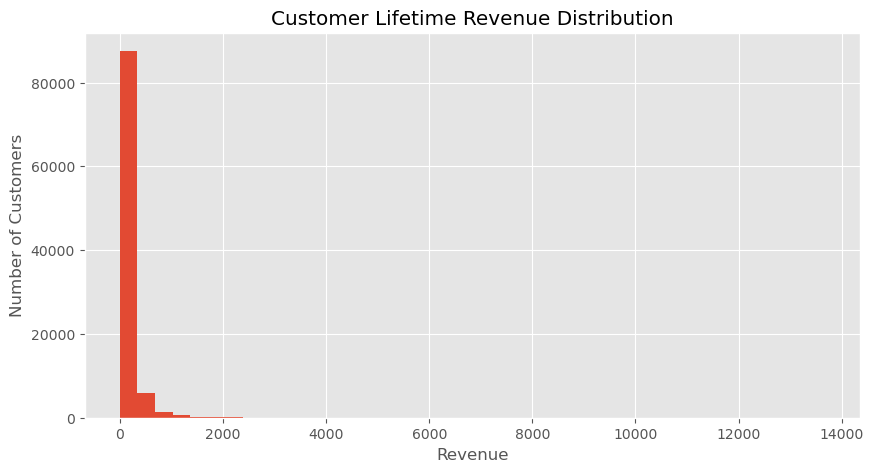

In [101]:
plt.figure(figsize=(10,5))

plt.hist(customer_lifetime_value['customer_revenue'], bins=40)
plt.title("Customer Lifetime Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Customers")

plt.show()

4) HIGHEST LIFETIME VALUE CONSUMER

In [102]:
highest_value_consumer = customer_lifetime_value.loc[customer_lifetime_value['customer_revenue'].idxmax()]
highest_value_consumer

customer_unique_id    0a0a92112bd4c708ca5fde585afaa872
customer_revenue                              13664.08
Name: 3826, dtype: object

5) TOP LIFETIME CONSUMERS

In [103]:
top_lifetime_consumers = (customer_lifetime_value.sort_values('customer_revenue', ascending=False).head(10))
top_lifetime_consumers

,customer_unique_id,customer_revenue
3826,0a0a92112bd4c708ca5fde585afaa872,13664.08
26456,46450c74a0d8c5ca9395da1daac6c120,9553.02
81962,da122df9eeddfedc1dc1f5349a1a690c,7571.63
44447,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
82808,dc4802a71eae9be1dd28f5d788ceb526,6929.31
26205,459bef486812aa25204be022145caa62,6922.21
95806,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
24121,4007669dec559734d6f53e029e360987,6081.54
35070,5d0a2980b292d049061542014e8960bf,4809.44
89688,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34


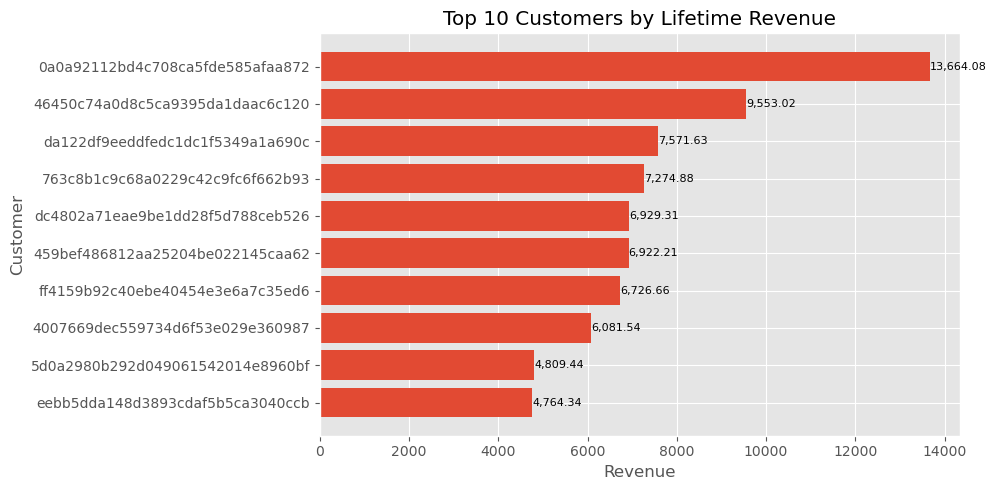

In [104]:
plt.figure(figsize=(10,5))

bars = plt.barh(
    top_lifetime_consumers['customer_unique_id'],
    top_lifetime_consumers['customer_revenue']
)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Lifetime Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer")

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.2f}",
        va='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()

# 7.PRODUCT ANALYTICS

1) TOP SELLING PRODUCTS

In [105]:
top_products = (items_master.groupby('product_id').agg(total_quantity = ('order_item_id', 'count'), revenue = ('price', 'sum')).reset_index())
top_products.head(10)

,product_id,total_quantity,revenue
0,00066f42aeeb9f3007548bb9d3f33c38,1,101.65
1,00088930e925c41fd95ebfe695fd2655,1,129.90
2,0009406fd7479715e4bef61dd91f2462,1,229.00
3,000b8f95fcb9e0096488278317764d19,2,117.80
4,000d9be29b5207b54e86aa1b1ac54872,1,199.00
5,0011c512eb256aa0dbbb544d8dffcf6e,1,52.00
6,00126f27c813603687e6ce486d909d01,2,498.00
7,001795ec6f1b187d37335e1c4704762e,9,350.10
8,001b237c0e9bb435f2e54071129237e9,1,78.90
9,001b72dfd63e9833e8c02742adf472e3,14,489.86


2) TOP 10 PRODUCTS

In [106]:
top_10_products = (top_products.sort_values('total_quantity', ascending=False).head(10))
top_10_products

,product_id,total_quantity,revenue
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527,37608.90
19742,99a4788cb24856965c36a24e339b6058,488,43025.56
8613,422879e10f46682990de24d770e7f83d,484,26577.22
7364,389d119b48cf3043d311335e499d9c6b,392,21440.59
7079,368c6c730842d78016ad823897a372db,388,21056.80
10840,53759a2ecddad2bb87a079a1f1519f73,373,20387.20
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343,47214.51
10867,53b36df67ebb7c41585e8d54d6772e08,323,37683.42
2794,154e7e31ebfa092203795c972e5804a6,281,6325.19
8051,3dd2a17168ec895c781a9191c1e95ad7,274,41082.60


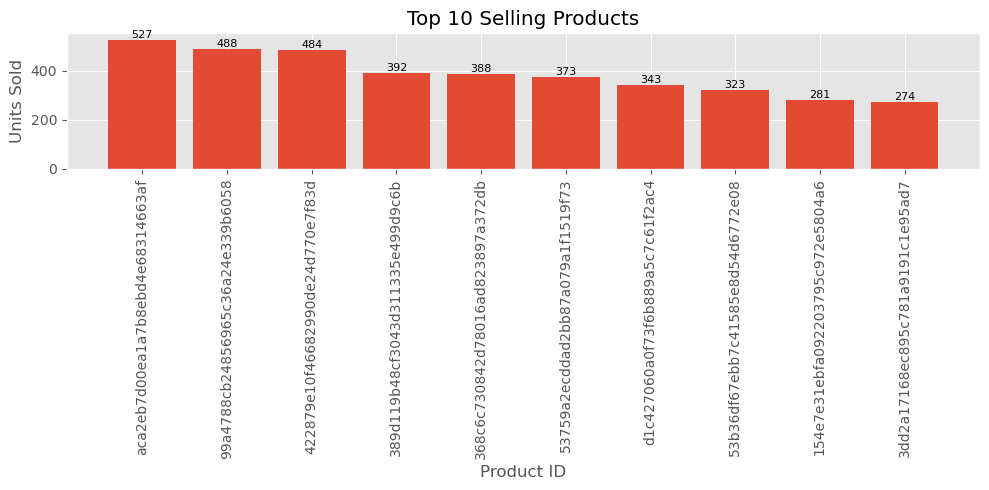

In [107]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    top_10_products['product_id'].astype(str),
    top_10_products['total_quantity']
)

plt.xticks(rotation=90)

plt.title("Top 10 Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Units Sold")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

3) TOP REVENUE PRODUCTS

In [108]:
top_revenue_products = (top_products.sort_values('revenue',ascending=False).head(10))
top_revenue_products

,product_id,total_quantity,revenue
24086,bb50f2e236e5eea0100680137654686c,195,63885.00
14068,6cdd53843498f92890544667809f1595,156,54730.20
27613,d6160fb7873f184099d9bc95e30376af,35,48899.34
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343,47214.51
19742,99a4788cb24856965c36a24e339b6058,488,43025.56
8051,3dd2a17168ec895c781a9191c1e95ad7,274,41082.60
4996,25c38557cf793876c5abdd5931f922db,38,38907.32
12351,5f504b3a1c75b73d6151be81eb05bdc9,63,37733.90
10867,53b36df67ebb7c41585e8d54d6772e08,323,37683.42
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527,37608.90


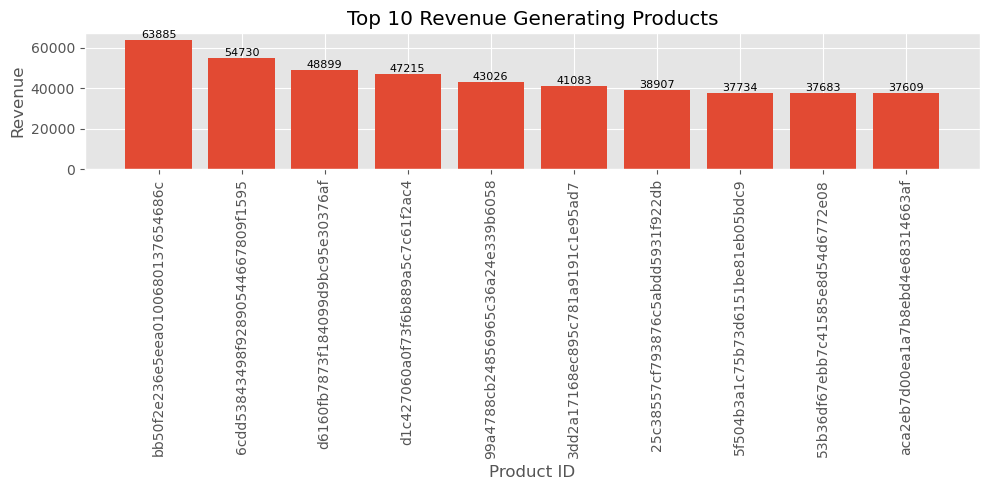

In [109]:
plt.figure(figsize=(10,5))

bars = plt.bar(top_revenue_products['product_id'].astype(str), top_revenue_products['revenue'])

plt.xticks(rotation=90)

plt.title("Top 10 Revenue Generating Products")
plt.xlabel("Product ID")
plt.ylabel("Revenue")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.0f}", ha = 'center', va = 'bottom', fontsize = 8)

plt.tight_layout()
plt.show()

# 8.SELLER PERFORMANCE ANALYTICS

1) SELLER PERFORMANCE

In [110]:
seller_summary = (items_master.groupby('seller_id').agg(total_orders = ('order_id', 'nunique'),
                                                     total_products_sold = ('order_item_id', 'count'),
                                                     total_revenue = ('price', 'sum')).reset_index())
seller_summary.head()

,seller_id,total_orders,total_products_sold,total_revenue
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,2685.00
1,001cca7ae9ae17fb1caed9dfb1094831,200,239,25080.03
2,001e6ad469a905060d959994f1b41e4f,1,1,250.00
3,002100f778ceb8431b7a1020ff7ab48f,51,55,1234.50
4,003554e2dce176b5555353e4f3555ac8,1,1,120.00


2) TOP SELLERS BY REVENUE

In [111]:
top_sellers_revenue = (seller_summary.sort_values('total_revenue', ascending=False).head(10))
top_sellers_revenue

,seller_id,total_orders,total_products_sold,total_revenue
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63
1013,53243585a1d6dc2643021fd1853d8905,358,410,222776.05
881,4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03
1535,7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89
1560,7e93a43ef30c4f03f38b393420bc753a,336,340,176431.87
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55
1824,955fee9216a65b617aa5c0531780ce60,1287,1499,135171.70


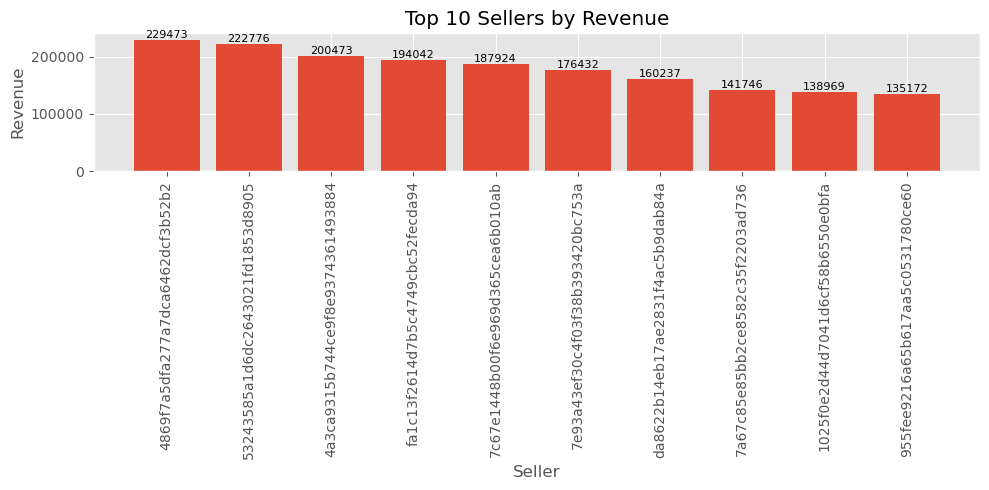

In [112]:
plt.figure(figsize=(10,5))

bars = plt.bar(top_sellers_revenue['seller_id'], top_sellers_revenue['total_revenue'])

plt.xticks(rotation = 90)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller")
plt.ylabel("Revenue")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.0f}", ha = 'center', va = 'bottom', fontsize = 8
    )

plt.tight_layout()
plt.show()

3) TOP SELLERS BY ORDERS

In [113]:
top_sellers_orders = (seller_summary.sort_values('total_orders', ascending=False).head())
top_sellers_orders

,seller_id,total_orders,total_products_sold,total_revenue
1235,6560211a19b47992c3666cc44a7e94c0,1854,2033,123304.83
881,4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92
2481,cc419e0650a3c5ba77189a1882b7556a,1706,1775,104288.42
368,1f50f920176fa81dab994f9023523100,1404,1931,106939.21
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57


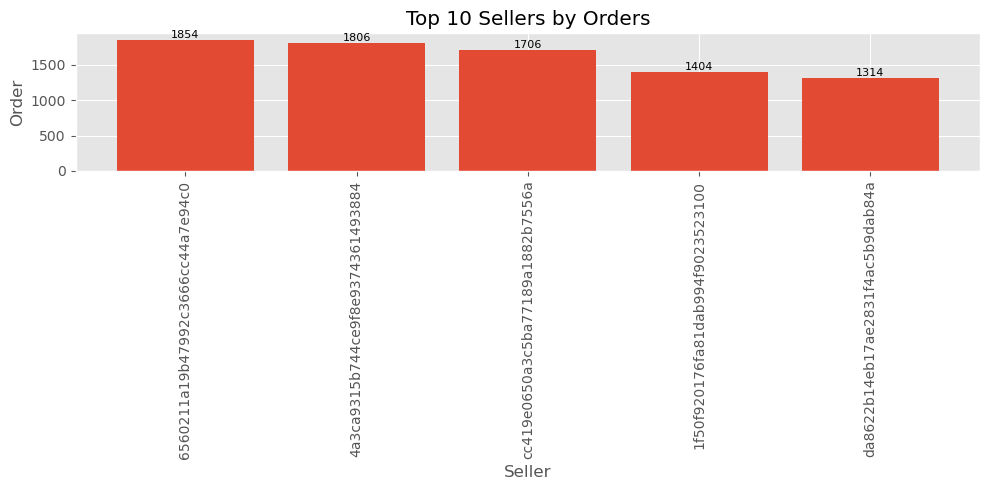

In [114]:
plt.figure(figsize=(10,5))

bars = plt.bar(top_sellers_orders['seller_id'], top_sellers_orders['total_orders'])

plt.xticks(rotation = 90)

plt.title("Top 10 Sellers by Orders")
plt.xlabel("Seller")
plt.ylabel("Order")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():.0f}", ha = 'center', va = 'bottom', fontsize = 8
    )

plt.tight_layout()
plt.show()

4) AVERAGE REVENUE PER SELLER

In [115]:
seller_summary['average_revenue_per_order'] = (seller_summary['total_revenue'] / seller_summary['total_orders'])
seller_summary.head()

,seller_id,total_orders,total_products_sold,total_revenue,average_revenue_per_order
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,2685.00,895.000000
1,001cca7ae9ae17fb1caed9dfb1094831,200,239,25080.03,125.400150
2,001e6ad469a905060d959994f1b41e4f,1,1,250.00,250.000000
3,002100f778ceb8431b7a1020ff7ab48f,51,55,1234.50,24.205882
4,003554e2dce176b5555353e4f3555ac8,1,1,120.00,120.000000


# 9.PAYMENT ANALYTICS

1) PAYMENT METHOD DISTRIBUTION

In [116]:
payment_summary = (orders_master.groupby('payment_type').agg(total_transactions = ('order_id', 'count'), total_revenue = ('total_payment', 'sum')).reset_index())
payment_summary

,payment_type,total_transactions,total_revenue
0,boleto,19784,2869361.27
1,credit_card,74259,12397278.59
2,"credit_card, debit_card",1,152.82
3,"credit_card, voucher",2245,338717.37
4,debit_card,1527,217939.79
5,not_defined,3,0.00
6,voucher,1621,185422.28


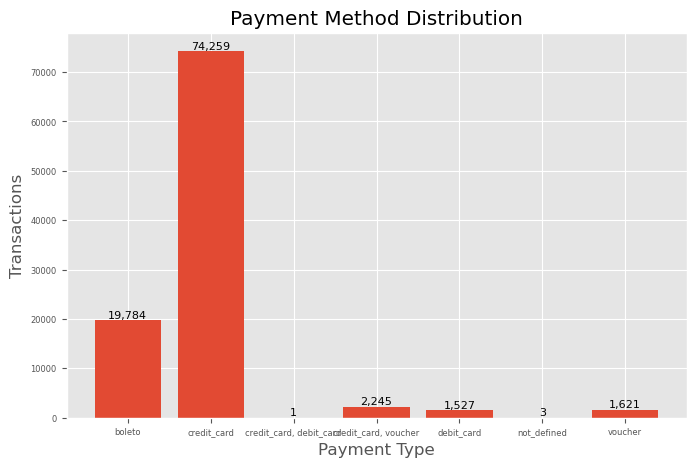

In [195]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    payment_summary['payment_type'],
    payment_summary['total_transactions']
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Transactions")

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha='center',
        va='bottom', fontsize = 8
    )

plt.show()

2) REVENUE BY PAYMENT METHOD

In [118]:
payment_revenue = (payment_summary.sort_values('total_revenue', ascending=False))
payment_revenue

,payment_type,total_transactions,total_revenue
1,credit_card,74259,12397278.59
0,boleto,19784,2869361.27
3,"credit_card, voucher",2245,338717.37
4,debit_card,1527,217939.79
6,voucher,1621,185422.28
2,"credit_card, debit_card",1,152.82
5,not_defined,3,0.00


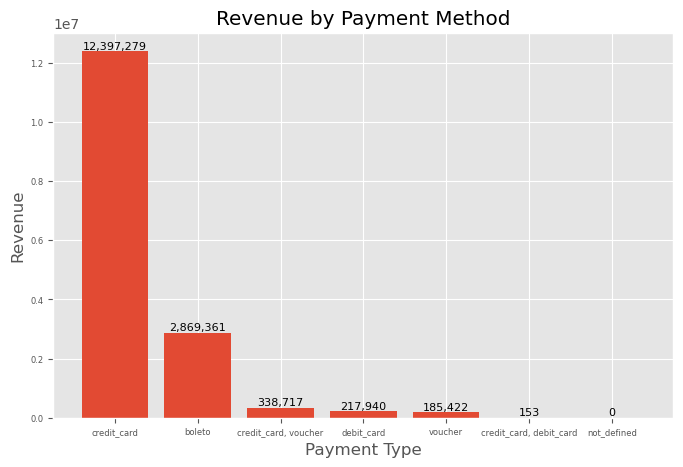

In [196]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    payment_revenue['payment_type'],
    payment_revenue['total_revenue']
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Type")
plt.ylabel("Revenue")

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.show()

3) INSTALLMENT ANALYSIS

In [120]:
installments = (orders_master.groupby('total_installments').agg(orders=('order_id','count'), revenue=('total_payment', 'sum')).reset_index())
installments


,total_installments,orders,revenue
0,0.0,2,188.63
1,1.0,48268,5842236.67
2,2.0,12363,1596366.86
3,3.0,10429,1505552.43
4,4.0,7070,1166974.43
5,5.0,5227,966412.81
6,6.0,3908,826910.66
7,7.0,1622,307102.14
8,8.0,4251,1316850.75
9,9.0,644,131749.22


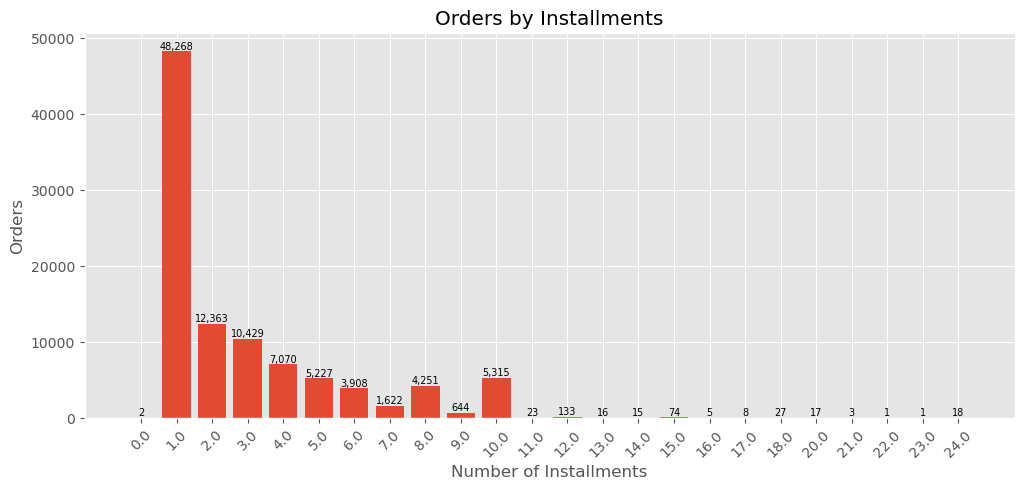

In [121]:
plt.figure(figsize=(12,5))

plt.title("Orders by Installments")
plt.xlabel("Number of Installments")
plt.ylabel("Orders")

bars = plt.bar(
    installments['total_installments'].astype(str),
    installments['orders']
)

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha='center',
        va='bottom',
        fontsize=7
    )


plt.show()

4) KEY PERFORMANCE INDICATOR

In [122]:
print("Most preferred payment method:")

payment_summary.loc[payment_summary['total_transactions'].idxmax()]

Most preferred payment method:


payment_type          credit_card
total_transactions          74259
total_revenue         12397278.59
Name: 1, dtype: object

# 10.CUSTOMER REVIEW ANALYTICS

1) REVIEW SCORE DISTRIBUTION

In [123]:
review_distribution = (
    orders_master
    .groupby('review_score')
    .size()
    .reset_index(name='reviews')
)

review_distribution

,review_score,reviews
0,1.000000,11316
1,1.500000,8
2,2.000000,3125
3,2.500000,34
4,3.000000,8136
5,3.333333,1
6,3.500000,25
7,4.000000,19018
8,4.333333,1
9,4.500000,54


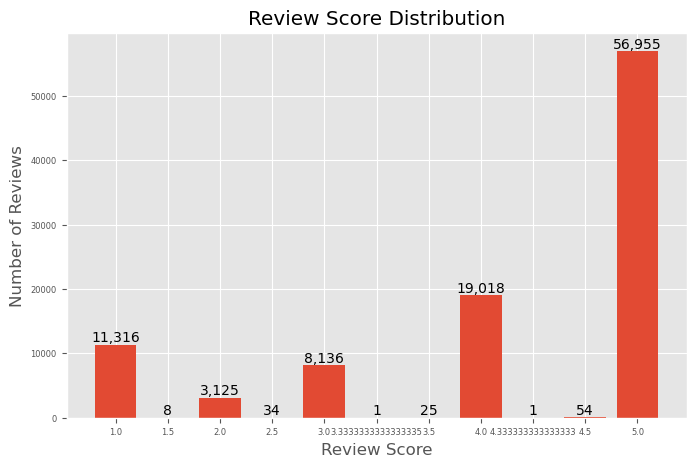

In [197]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    review_distribution['review_score'].astype(str),
    review_distribution['reviews']
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha='center',
        va='bottom'
    )

plt.show()

2) AVERAGE REVIEW SCORE

In [125]:
average_rating = orders_master['review_score'].mean()

print(f"Average Review Score: {average_rating:.2f}")

Average Review Score: 4.09


3) REVENUE BY REVIEW SCORE

In [126]:
review_revenue = (
    orders_master
    .groupby('review_score')
    .agg(
        revenue=('total_payment', 'sum'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

review_revenue

,review_score,revenue,orders
0,1.000000,2215606.73,11316
1,1.500000,1637.63,8
2,2.000000,540508.93,3125
3,2.500000,4489.81,34
4,3.000000,1233804.75,8136
5,3.333333,42.11,1
6,3.500000,3591.14,25
7,4.000000,2945293.29,19018
8,4.333333,42.77,1
9,4.500000,6582.05,54


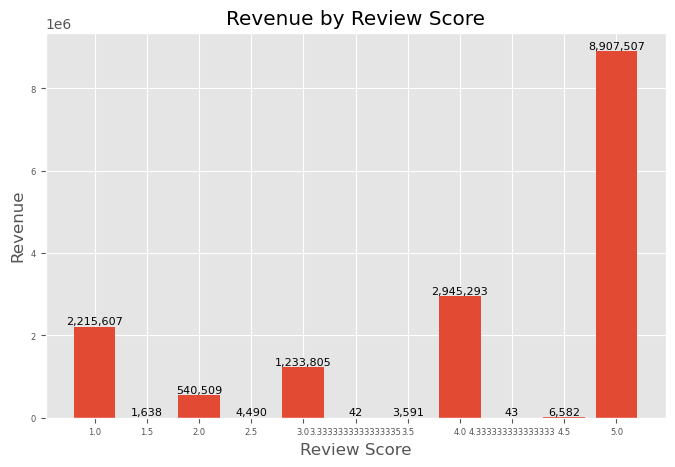

In [198]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    review_revenue['review_score'].astype(str),
    review_revenue['revenue']
)

plt.title("Revenue by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Revenue")

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.show()

4) DELIVERY TIME vs REVIEW SCORE

In [128]:
delivery_review = (
    orders_master
    .groupby('review_score')['delivery_days']
    .mean()
    .reset_index()
)

delivery_review

,review_score,delivery_days
0,1.000000,20.878489
1,1.500000,17.000000
2,2.000000,16.198560
3,2.500000,18.266667
4,3.000000,13.780066
5,3.333333,22.000000
6,3.500000,12.913043
7,4.000000,11.842803
8,4.333333,3.000000
9,4.500000,12.301887


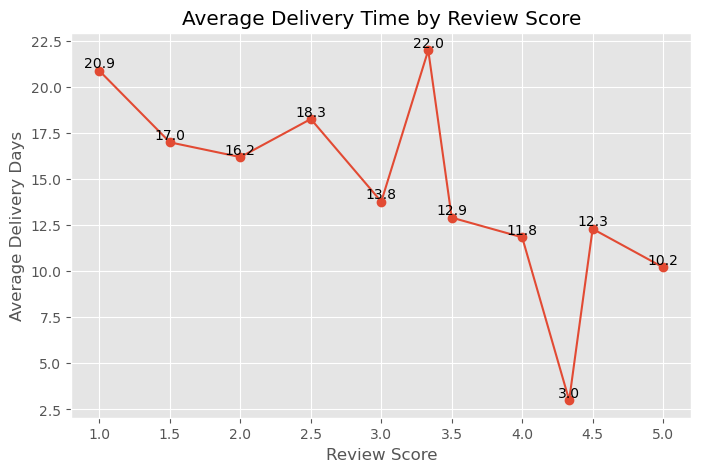

In [129]:
plt.figure(figsize=(8,5))

plt.plot(delivery_review['review_score'], delivery_review['delivery_days'], marker = 'o')

for x,y in zip(delivery_review['review_score'], delivery_review['delivery_days']):
    plt.text(x,y,f"{y:.1f}", ha = 'center', va = 'bottom')

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Days")

plt.grid(True)

plt.show()

5) KPI

In [130]:
highest_rating = review_distribution.loc[review_distribution['reviews'].idxmax()]
highest_rating

review_score        5.0
reviews         56955.0
Name: 10, dtype: float64

# 11.GEOGRAPHIC ANALYTICS

1) REVENUE BY STATE

In [131]:
state_revenue = (orders_master.groupby('customer_state').agg(revenue = ('total_payment', 'sum'), orders = ('order_id', 'nunique')).reset_index())
state_revenue

,customer_state,revenue,orders
0,AC,19680.62,81
1,AL,96962.06,413
2,AM,27966.93,148
3,AP,16262.80,68
4,BA,616645.82,3380
5,CE,279464.03,1336
6,DF,355141.08,2140
7,ES,325967.55,2033
8,GO,350092.31,2020
9,MA,152523.02,747


2) TOP 10 STATES BY REVENUE

In [132]:
top_10_states_by_revenue = (state_revenue.sort_values('revenue', ascending=False).head(10))
top_10_states_by_revenue

,customer_state,revenue,orders
25,SP,5998226.96,41746
18,RJ,2144379.69,12852
10,MG,1872257.26,11635
22,RS,890898.54,5466
17,PR,811156.38,5045
23,SC,623086.43,3637
4,BA,616645.82,3380
6,DF,355141.08,2140
8,GO,350092.31,2020
7,ES,325967.55,2033


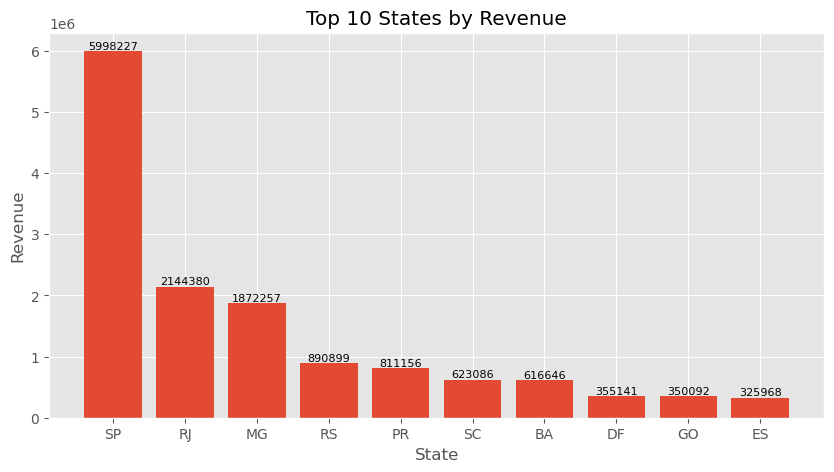

In [133]:
plt.figure(figsize=(10,5))

bars = plt.bar(top_10_states_by_revenue['customer_state'], top_10_states_by_revenue['revenue'])

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{bar.get_height():.0f}", ha = 'center', va = 'bottom', fontsize=8)

plt.show()

3) ORDERS BY STATE

In [134]:
state_orders = (orders_master.groupby('customer_state').agg(orders = ('order_id', 'nunique')).reset_index())
state_orders

,customer_state,orders
0,AC,81
1,AL,413
2,AM,148
3,AP,68
4,BA,3380
5,CE,1336
6,DF,2140
7,ES,2033
8,GO,2020
9,MA,747


4) TOP 10 STATES BY ORDERS

In [135]:
top_10_states_by_orders = (state_orders.sort_values('orders', ascending=False).head(10))
top_10_states_by_orders

,customer_state,orders
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


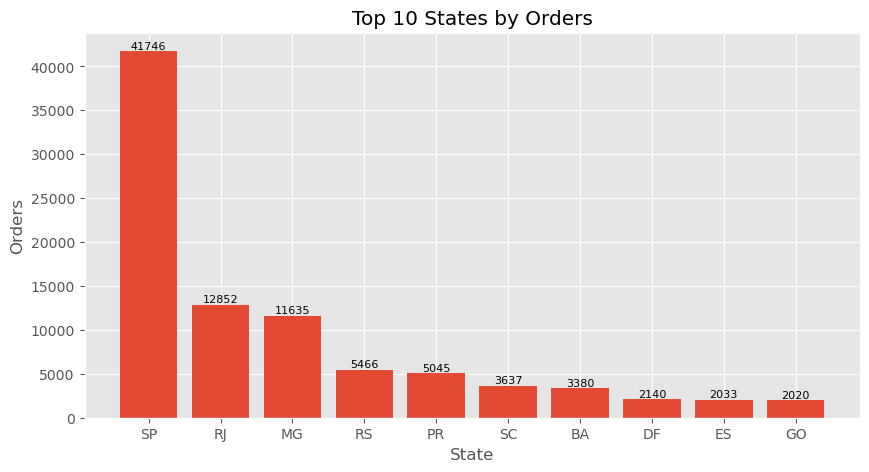

In [136]:
plt.figure(figsize=(10,5))

bars = plt.bar(top_10_states_by_orders['customer_state'], top_10_states_by_orders['orders'])

plt.title("Top 10 States by Orders")
plt.xlabel("State")
plt.ylabel("Orders")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{bar.get_height():.0f}", ha = 'center', va = 'bottom', fontsize=8)

plt.show()

5) REVENUE BY CITY

In [137]:
city_revenue = (orders_master.groupby('customer_city').agg(revenue = ('total_payment', 'sum'), orders = ('order_id', 'nunique')).reset_index())
city_revenue

,customer_city,revenue,orders
0,abadia dos dourados,413.50,3
1,abadiania,1025.52,1
2,abaete,1946.81,12
3,abaetetuba,4672.27,11
4,abaiara,332.15,2
...,...,...,...
4114,xinguara,1608.51,9
4115,xique-xique,230.56,3
4116,zacarias,229.85,2
4117,ze doca,878.92,5


6) TOP 10 CITIES BY REVENUE

In [138]:
top_10_cities_by_revenue = (city_revenue.sort_values('revenue', ascending=False).head(10))
top_10_cities_by_revenue

,customer_city,revenue,orders
3597,sao paulo,2203373.09,15540
3155,rio de janeiro,1161927.36,6882
453,belo horizonte,421765.12,2773
558,brasilia,354216.78,2131
1143,curitiba,247392.48,1521
2964,porto alegre,224731.42,1379
3247,salvador,218071.50,1245
707,campinas,216248.43,1444
1529,guarulhos,165121.99,1189
2461,niteroi,139996.99,849


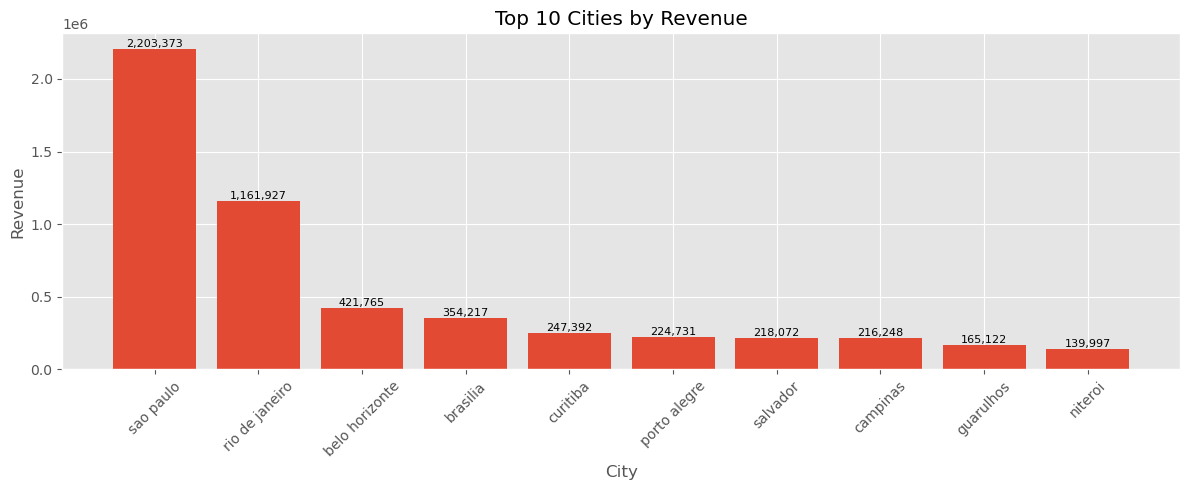

In [139]:
plt.figure(figsize=(12,5))

bars = plt.bar(
    top_10_cities_by_revenue['customer_city'],
    top_10_cities_by_revenue['revenue']
)

plt.xticks(rotation=45)

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()

plt.show()

7) ORDERS BY CITY

In [140]:
city_orders = (orders_master.groupby('customer_city').agg(orders = ('order_id', 'nunique')).reset_index())
city_orders

,customer_city,orders
0,abadia dos dourados,3
1,abadiania,1
2,abaete,12
3,abaetetuba,11
4,abaiara,2
...,...,...
4114,xinguara,9
4115,xique-xique,3
4116,zacarias,2
4117,ze doca,5


8) TOP 10 CITIES BY ORDERS

In [141]:
top_10_cities_by_orders = (city_orders.sort_values('orders', ascending=False).head(10))
top_10_cities_by_orders

,customer_city,orders
3597,sao paulo,15540
3155,rio de janeiro,6882
453,belo horizonte,2773
558,brasilia,2131
1143,curitiba,1521
707,campinas,1444
2964,porto alegre,1379
3247,salvador,1245
1529,guarulhos,1189
3428,sao bernardo do campo,938


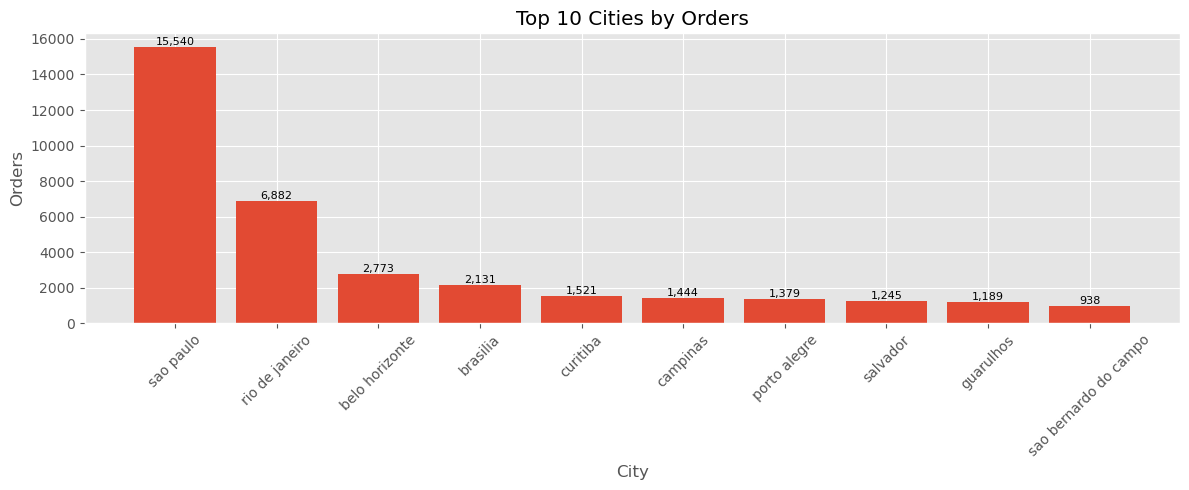

In [142]:
plt.figure(figsize=(12,5))

bars = plt.bar(
    top_10_cities_by_orders['customer_city'],
    top_10_cities_by_orders['orders']
)

plt.xticks(rotation=45)

plt.title("Top 10 Cities by Orders")
plt.xlabel("City")
plt.ylabel("Orders")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()

plt.show()

9) HIGHEST REVENUE STATE

In [143]:
highest_revenue_state = state_revenue.loc[
    state_revenue['revenue'].idxmax()
]

highest_revenue_state

customer_state            SP
revenue           5998226.96
orders                 41746
Name: 25, dtype: object

10) HIGHEST ORDER STATE

In [144]:
highest_order_state = state_orders.loc[
    state_orders['orders'].idxmax()
]

highest_order_state

customer_state       SP
orders            41746
Name: 25, dtype: object

# 12.DELIVERY & LOGISTICS ANALYSIS

1) AVERAGE DELIVERY TIME

In [145]:
average_delivery = orders_master['delivery_days'].mean()
print(f"Average Delivery Days: {average_delivery:.0f}days")

Average Delivery Days: 12days


2) DELIVERY TIME DISTRIBUTION

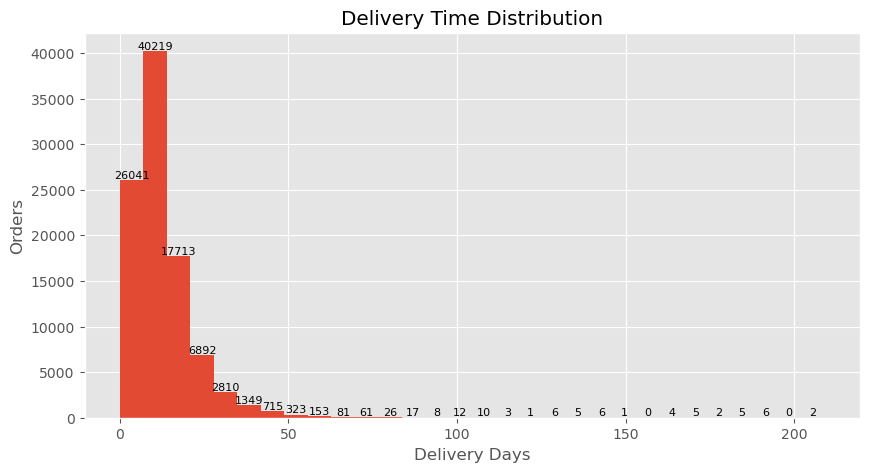

In [146]:
plt.figure(figsize=(10,5))

counts, bins, patches = plt.hist(
    orders_master['delivery_days'].dropna(),
    bins=30
)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Orders")

for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width()/2,
        count,
        int(count),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.show()

3) AVERAGE DELIVERY TIME BY STATE

In [147]:
delivery_state = (orders_master.groupby('customer_state').agg(avg_delivery = ('delivery_days', 'mean')).reset_index())
delivery_state

,customer_state,avg_delivery
0,AC,20.637500
1,AL,24.040302
2,AM,25.986207
3,AP,26.731343
4,BA,18.866400
5,CE,20.817826
6,DF,12.509135
7,ES,15.331830
8,GO,15.151763
9,MA,21.117155


4) TOP 10 SLOWEST STATES

In [148]:
slowest_states = (delivery_state.sort_values('avg_delivery', ascending=False).head(10))
slowest_states

,customer_state,avg_delivery
21,RR,28.975610
3,AP,26.731343
2,AM,25.986207
1,AL,24.040302
13,PA,23.316068
9,MA,21.117155
24,SE,21.029851
5,CE,20.817826
0,AC,20.637500
14,PB,19.953578


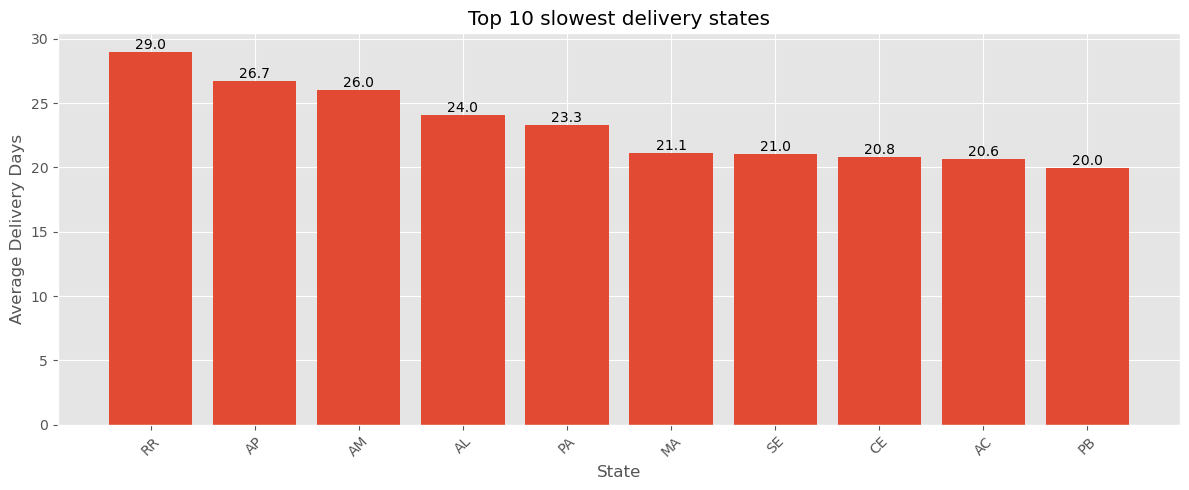

In [149]:
plt.figure(figsize=(12,5))

bars = plt.bar(
    slowest_states['customer_state'],
    slowest_states['avg_delivery']
)

plt.xticks(rotation=45)

plt.title("Top 10 slowest delivery states")
plt.xlabel("State")
plt.ylabel("Average Delivery Days")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.show()

5. TOP 10 FASTEST DELIVERY STATES

In [150]:
fastest_states = (delivery_state.sort_values('avg_delivery').head(10))
fastest_states

,customer_state,avg_delivery
25,SP,8.298481
17,PR,11.527321
10,MG,11.544694
6,DF,12.509135
23,SC,14.480124
22,RS,14.819611
18,RJ,14.849510
8,GO,15.151763
11,MS,15.191155
7,ES,15.331830


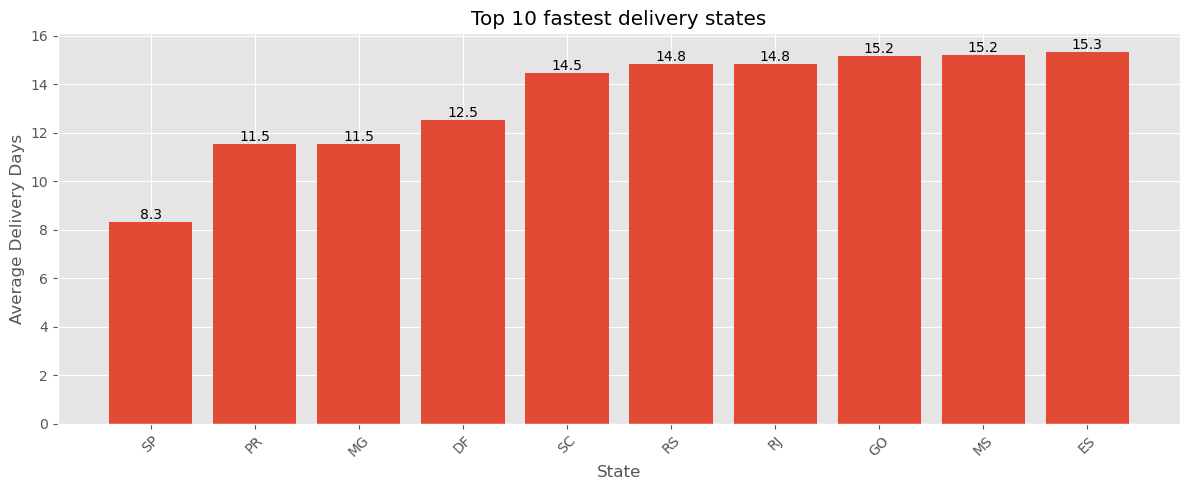

In [151]:
plt.figure(figsize=(12,5))

bars = plt.bar(
    fastest_states['customer_state'],
    fastest_states['avg_delivery'])


plt.xticks(rotation=45)

plt.title("Top 10 fastest delivery states")
plt.xlabel("State")
plt.ylabel("Average Delivery Days")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.show()

6. LATE DELIVERIES

In [152]:
late_deliveries = (orders_master['estimated_delivery_gap'] > 0).sum()

total_delivered = orders_master['estimated_delivery_gap'].notna().sum()

late_percentage = (late_deliveries / total_delivered) * 100

print(f"Late Delivery %: {late_percentage:.2f}%")

Late Delivery %: 6.77%


7) EARLY DELIVERIES vs LATE DELIVERIES

In [153]:
delivery_status = pd.DataFrame({"Status": ['Early/On-Time', 'Late'],"Orders": [ total_delivered-late_deliveries, late_deliveries ]})
delivery_status

,Status,Orders
0,Early/On-Time,89941
1,Late,6535


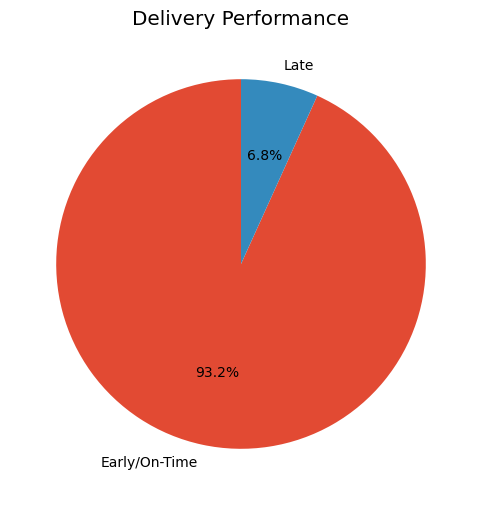

In [154]:
plt.figure(figsize=(6,6))

plt.pie(delivery_status['Orders'], labels=delivery_status['Status'], autopct='%1.1f%%', startangle=90)
plt.title("Delivery Performance")

plt.show()

8. APPROVAL TIME

In [155]:
orders['approval_hours'] = (orders['order_approved_at']-orders['order_purchase_timestamp']).dt.total_seconds()/3600
orders['approval_hours']

0         0.183333
1        30.716667
2         0.283333
3         0.283333
4         1.033333
           ...    
99436     0.000000
99437     0.200000
99438     0.300000
99439     0.133333
99440    14.383333
Name: approval_hours, Length: 99441, dtype: float64

# 13.RFM CUSTOMER SEGMENTATION

1) SNAPSHOT DATE

In [156]:
snapshot_date = orders_master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2018-10-18 17:30:00')

2) RFM TABLE

In [157]:
rfm = (orders_master.groupby('customer_unique_id').agg(Recency = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
                                                   Frequency=('order_id', 'nunique'),
                                                   Monetary=('total_payment', 'sum')).reset_index())
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [158]:
rfm.describe()

,Recency,Frequency,Monetary
count,96096.000000,96096.000000,96096.000000
mean,288.736253,1.034809,166.592492
std,153.414682,0.214384,231.428332
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,63.120000
50%,269.000000,1.000000,108.000000
75%,398.000000,1.000000,183.530000
max,773.000000,17.000000,13664.080000


3) R-SCORE

In [159]:
rfm['R-Score'] = pd.qcut(rfm['Recency'], 5, labels=[1,2,3,4,5])
rfm['R-Score']

0        2
1        2
2        5
3        4
4        4
        ..
96091    5
96092    3
96093    5
96094    2
96095    5
Name: R-Score, Length: 96096, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

4) F-SCORE

In [160]:
rfm['F-Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),5, labels=[1,2,3,4,5])
rfm['F-Score']

0        1
1        1
2        1
3        1
4        1
        ..
96091    5
96092    5
96093    5
96094    5
96095    5
Name: F-Score, Length: 96096, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

5) M-SCORE

In [161]:
rfm['M-Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)
rfm['M-Score']

0        4
1        1
2        2
3        1
4        4
        ..
96091    5
96092    2
96093    3
96094    4
96095    2
Name: M-Score, Length: 96096, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [162]:
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R-Score,F-Score,M-Score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,2,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,2,1,1
2,0000f46a3911fa3c0805444483337064,586,1,86.22,5,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,4,1,1
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,4,1,4


6) RFM SCORE

In [163]:
rfm['RFM-Score'] = (rfm['R-Score'].astype(str) + rfm['F-Score'].astype(str) + rfm['M-Score'].astype(str))
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R-Score,F-Score,M-Score,RFM-Score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,2,1,4,214
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,2,1,1,211
2,0000f46a3911fa3c0805444483337064,586,1,86.22,5,1,2,512
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,4,1,1,411
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,4,1,4,414


In [164]:
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R-Score,F-Score,M-Score,RFM-Score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,2,1,4,214
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,2,1,1,211
2,0000f46a3911fa3c0805444483337064,586,1,86.22,5,1,2,512
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,4,1,1,411
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,4,1,4,414


6) CUSTOMER SEGMENTS

In [165]:
def segment_customer(row):
    if row['R-Score'] >= 4 and row['F-Score'] >= 4:
        return "Champions"
    
    elif row['R-Score'] >= 3 and row['F-Score'] >= 4:
        return "Loyal Customers"
    
    elif row['R-Score'] >= 4 and row['F-Score'] >= 2:
        return "Potential Loyal Customers"
    
    elif row['R-Score'] >= 3 and row['F-Score'] >= 2:
        return "Promising"
    
    elif row['R-Score'] == 2:
        return "Needs Atention"
    
    elif row['R-Score'] == 1:
        return "At Risk"
    
    else:
        return "Lost Customers"

In [166]:
rfm['customer_segments'] = rfm.apply(segment_customer, axis=1)
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R-Score,F-Score,M-Score,RFM-Score,customer_segments
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,2,1,4,214,Needs Atention
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,2,1,1,211,Needs Atention
2,0000f46a3911fa3c0805444483337064,586,1,86.22,5,1,2,512,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,4,1,1,411,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,4,1,4,414,Lost Customers


7) SEGMENT SUMMARY

In [167]:
segment_summary = (rfm.groupby('customer_segments').agg(Customers = ('customer_unique_id', 'count'), Revenue = ('Monetary', 'sum'), 
                                                       Avg_Recency = ('Recency', 'mean'), Avg_Frequency = ('Frequency', 'mean')).reset_index())
segment_summary

,customer_segments,Customers,Revenue,Avg_Recency,Avg_Frequency
0,At Risk,19324,3310531.90,95.167305,1.042124
1,Champions,15286,2621357.39,445.810938,1.074513
2,Lost Customers,11500,1846557.90,389.751478,1.000000
3,Loyal Customers,7699,1260892.90,271.358878,1.088713
4,Needs Atention,19299,3288361.51,186.445308,1.036738
5,Potential Loyal Customers,15406,2529561.27,445.653382,1.000000
6,Promising,7582,1151609.25,271.358744,1.000000


In [168]:
segment_summary = segment_summary.sort_values('Customers', ascending=False)
segment_summary

,customer_segments,Customers,Revenue,Avg_Recency,Avg_Frequency
0,At Risk,19324,3310531.90,95.167305,1.042124
4,Needs Atention,19299,3288361.51,186.445308,1.036738
5,Potential Loyal Customers,15406,2529561.27,445.653382,1.000000
1,Champions,15286,2621357.39,445.810938,1.074513
2,Lost Customers,11500,1846557.90,389.751478,1.000000
3,Loyal Customers,7699,1260892.90,271.358878,1.088713
6,Promising,7582,1151609.25,271.358744,1.000000


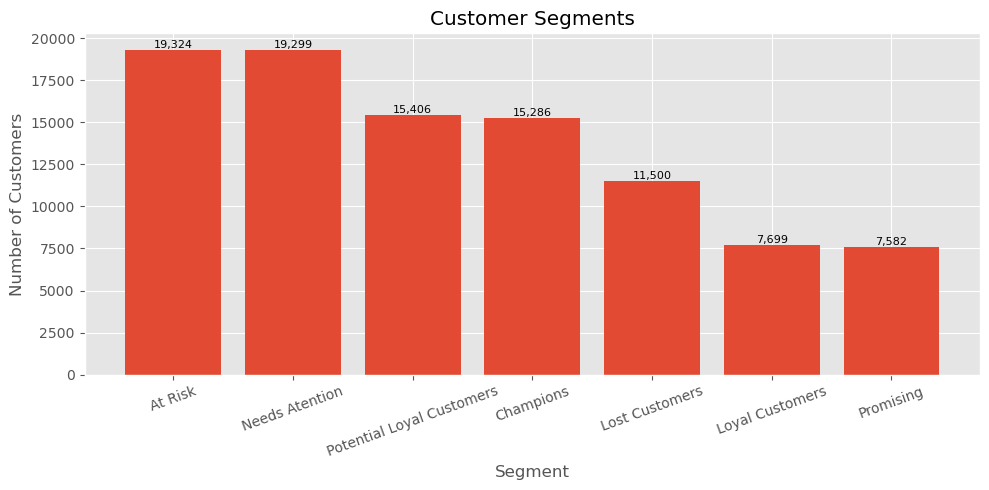

In [169]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    segment_summary['customer_segments'],
    segment_summary['Customers']
)

plt.xticks(rotation=20)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

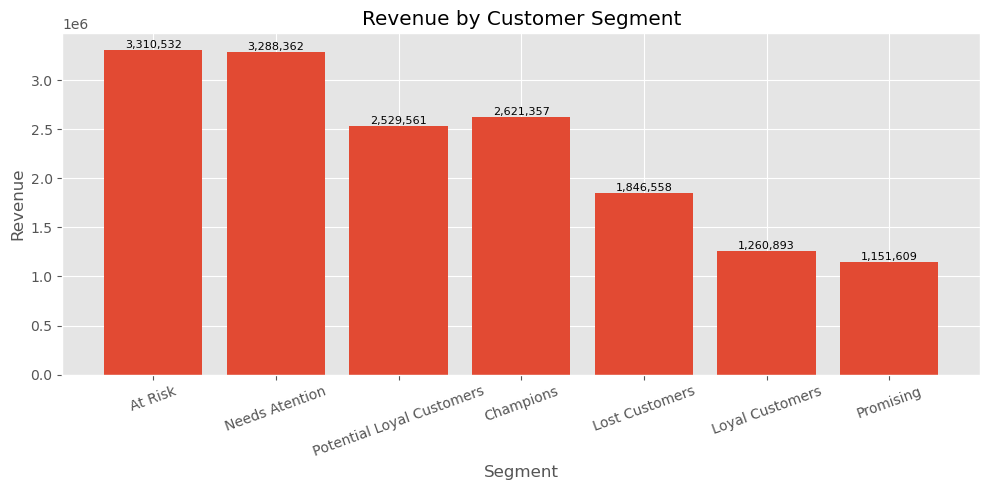

In [170]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    segment_summary['customer_segments'],
    segment_summary['Revenue']
)

plt.xticks(rotation=20)

plt.title("Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

# 14.PARETO ANALYSIS

1) REVENUE BY CUSTOMER

In [171]:
customer_revenue = (orders_master.groupby('customer_unique_id').agg(Revenue = ('total_payment', 'sum')).reset_index())
customer_revenue

,customer_unique_id,Revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89
...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,2067.42
96092,fffea47cd6d3cc0a88bd621562a9d061,84.58
96093,ffff371b4d645b6ecea244b27531430a,112.46
96094,ffff5962728ec6157033ef9805bacc48,133.69


In [172]:
customer_revenue = customer_revenue .sort_values('Revenue', ascending=False)
customer_revenue.head(10)

,customer_unique_id,Revenue
3826,0a0a92112bd4c708ca5fde585afaa872,13664.08
26456,46450c74a0d8c5ca9395da1daac6c120,9553.02
81962,da122df9eeddfedc1dc1f5349a1a690c,7571.63
44447,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
82808,dc4802a71eae9be1dd28f5d788ceb526,6929.31
26205,459bef486812aa25204be022145caa62,6922.21
95806,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
24121,4007669dec559734d6f53e029e360987,6081.54
35070,5d0a2980b292d049061542014e8960bf,4809.44
89688,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34


2) CUMULATIVE REVENUE

In [173]:
customer_revenue['cumulative_revenue'] = (customer_revenue['Revenue'].cumsum())
customer_revenue['cumulative_revenue_%'] = (
    customer_revenue['cumulative_revenue']
    / customer_revenue['Revenue'].sum()
) * 100


In [174]:
customer_revenue.head()

,customer_unique_id,Revenue,cumulative_revenue,cumulative_revenue_%
3826,0a0a92112bd4c708ca5fde585afaa872,13664.08,13664.08,0.085353
26456,46450c74a0d8c5ca9395da1daac6c120,9553.02,23217.10,0.145026
81962,da122df9eeddfedc1dc1f5349a1a690c,7571.63,30788.73,0.192323
44447,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,38063.61,0.237766
82808,dc4802a71eae9be1dd28f5d788ceb526,6929.31,44992.92,0.281050


3) CUSTOMER PERCENTAGE

In [175]:
customer_revenue['customer_%'] = (np.arange(1, len(customer_revenue)+1)/len(customer_revenue))*100
customer_revenue.head()

,customer_unique_id,Revenue,cumulative_revenue,cumulative_revenue_%,customer_%
3826,0a0a92112bd4c708ca5fde585afaa872,13664.08,13664.08,0.085353,0.001041
26456,46450c74a0d8c5ca9395da1daac6c120,9553.02,23217.10,0.145026,0.002081
81962,da122df9eeddfedc1dc1f5349a1a690c,7571.63,30788.73,0.192323,0.003122
44447,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,38063.61,0.237766,0.004163
82808,dc4802a71eae9be1dd28f5d788ceb526,6929.31,44992.92,0.281050,0.005203


4) PARETO CURVE

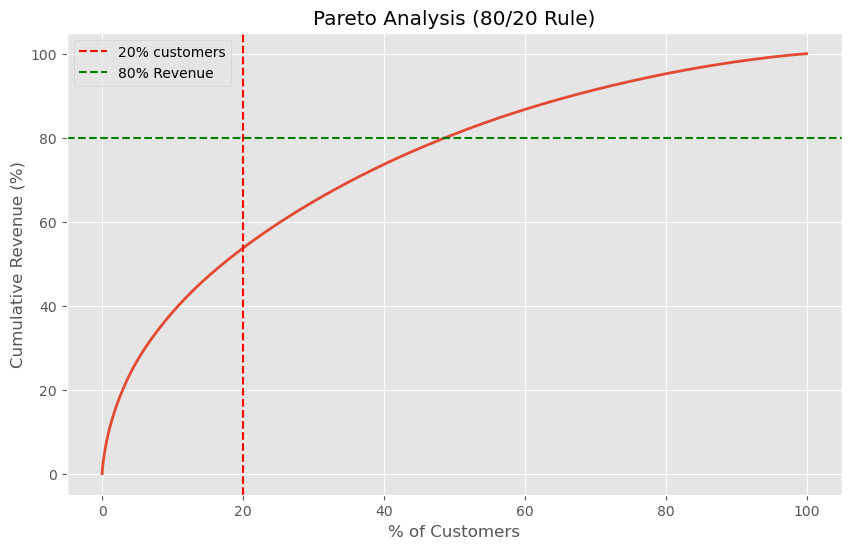

In [176]:
plt.figure(figsize=(10,6))

plt.plot(customer_revenue['customer_%'], customer_revenue['cumulative_revenue_%'], linewidth = 2)
plt.axvline(20,color = 'red', linestyle ='--', label = '20% customers')
plt.axhline(80,color='green', linestyle='--', label='80% Revenue')
plt.title("Pareto Analysis (80/20 Rule)")
plt.xlabel("% of Customers")
plt.ylabel("Cumulative Revenue (%)")

plt.legend()

plt.grid(True)

plt.show()

5) ACTUAL PERCENTAGE OF CUSOMERS NEEDED TO GENERATE 80% REVENUE

In [177]:
customers_for_80 = customer_revenue[customer_revenue['cumulative_revenue_%'] >= 80].iloc[0]
customers_for_80

customer_unique_id      b75acdce1eac184bad37d6f19326f5a5
Revenue                                           111.58
cumulative_revenue                           12807157.92
cumulative_revenue_%                           80.000376
customer_%                                     48.665917
Name: 68916, dtype: object

6) KEY PERFORMANCE INDICATOR

In [178]:
print(
    f"{customers_for_80['customer_%']:.2f}% of customers generate 80% of total revenue."
)

48.67% of customers generate 80% of total revenue.


# 15.CORRELATION ANALYSIS

1) ORDER LEVEL CORRELATION DATAFRAME

In [179]:
correlation_orders = orders_master[
    [
        'total_payment',
        'delivery_days',
        'estimated_delivery_gap',
        'review_score'
    ]
]

In [180]:
correlation_orders

,total_payment,delivery_days,estimated_delivery_gap,review_score
0,38.71,8.0,-8.0,4.0
1,141.46,13.0,-6.0,4.0
2,179.12,9.0,-18.0,5.0
3,72.20,13.0,-13.0,5.0
4,28.62,2.0,-10.0,5.0
...,...,...,...,...
99436,85.08,8.0,-11.0,5.0
99437,195.00,22.0,-2.0,4.0
99438,271.01,24.0,-6.0,5.0
99439,441.16,17.0,-21.0,2.0


2) ORDER LEVEL CORRELATION MATRIX

In [181]:
corr_orders = correlation_orders.corr()

corr_orders

,total_payment,delivery_days,estimated_delivery_gap,review_score
total_payment,1.000000,0.069484,-0.017743,-0.049137
delivery_days,0.069484,1.000000,0.607712,-0.334160
estimated_delivery_gap,-0.017743,0.607712,1.000000,-0.266990
review_score,-0.049137,-0.334160,-0.266990,1.000000


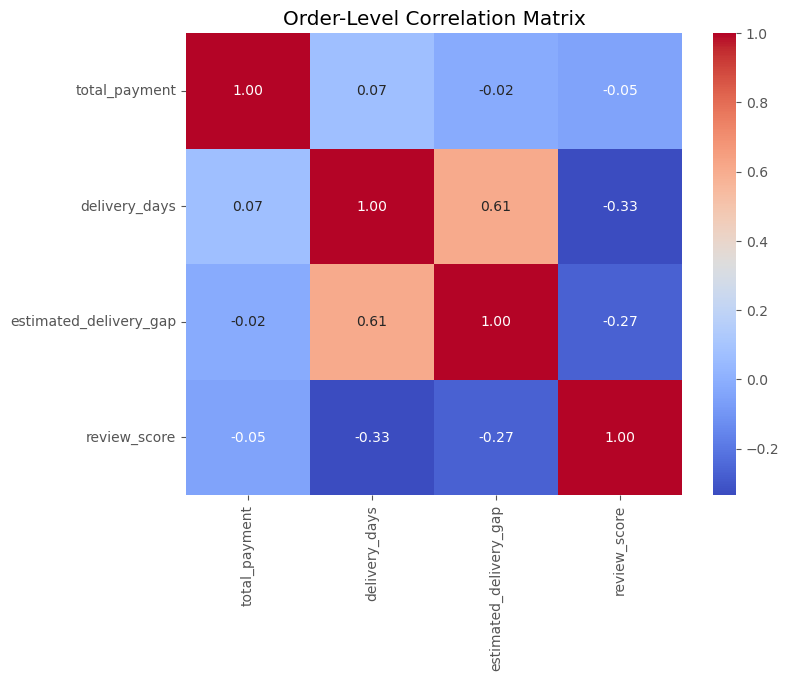

In [182]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_orders,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Order-Level Correlation Matrix")

plt.show()

3. PRODUCT LEVEL CORRELATION DATAFRAME

In [183]:
correlation_products = items_master[
    [
        'price',
        'freight_value',
        'product_weight_g',
        'product_length_cm',
        'product_height_cm',
        'product_width_cm'
    ]
]

In [184]:
correlation_products

,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,58.90,13.29,650.0,28.0,9.0,14.0
1,239.90,19.93,30000.0,50.0,30.0,40.0
2,199.00,17.87,3050.0,33.0,13.0,33.0
3,12.99,12.79,200.0,16.0,10.0,15.0
4,199.90,18.14,3750.0,35.0,40.0,30.0
...,...,...,...,...,...,...
112645,299.99,43.41,10150.0,89.0,15.0,40.0
112646,350.00,36.53,8950.0,45.0,26.0,38.0
112647,99.90,16.95,967.0,21.0,24.0,19.0
112648,55.99,8.72,100.0,20.0,20.0,20.0


4. PRODUCT CORRELATION MATRIX

In [185]:
corr_products = correlation_products.corr()

corr_products

,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm
price,1.000000,0.414204,0.338819,0.145811,0.223602,0.172467
freight_value,0.414204,1.000000,0.610420,0.309086,0.391831,0.323777
product_weight_g,0.338819,0.610420,1.000000,0.460919,0.583277,0.506609
product_length_cm,0.145811,0.309086,0.460919,1.000000,0.192895,0.532537
product_height_cm,0.223602,0.391831,0.583277,0.192895,1.000000,0.281224
product_width_cm,0.172467,0.323777,0.506609,0.532537,0.281224,1.000000


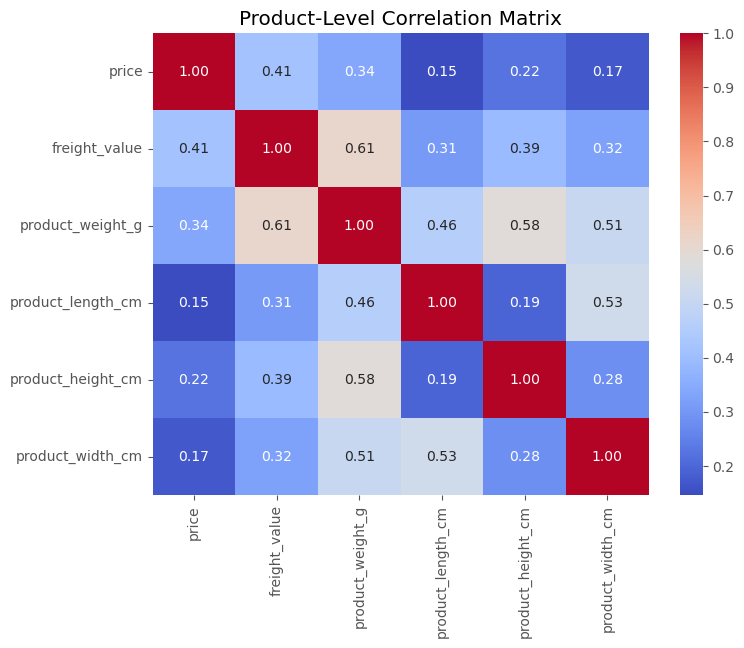

In [186]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_products,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Product-Level Correlation Matrix")

plt.show()

3) REVENUE RELATIONSHIPS

In [187]:
corr_orders['total_payment'].sort_values(ascending=False)

total_payment             1.000000
delivery_days             0.069484
estimated_delivery_gap   -0.017743
review_score             -0.049137
Name: total_payment, dtype: float64

3) DELIVERY RELATIONSHIPS

In [188]:
corr_orders['delivery_days'].sort_values(ascending=False)

delivery_days             1.000000
estimated_delivery_gap    0.607712
total_payment             0.069484
review_score             -0.334160
Name: delivery_days, dtype: float64

4) FREIGHT RELATIONSHIPS

In [189]:
corr_products['freight_value'].sort_values(ascending=True)

product_length_cm    0.309086
product_width_cm     0.323777
product_height_cm    0.391831
price                0.414204
product_weight_g     0.610420
freight_value        1.000000
Name: freight_value, dtype: float64

5) REVIEW SCORE RELATIONSHIPS

In [190]:
corr_orders['review_score'].sort_values(ascending=True)

delivery_days            -0.334160
estimated_delivery_gap   -0.266990
total_payment            -0.049137
review_score              1.000000
Name: review_score, dtype: float64

# **15.KEY BUSINESS INSIGHTS**

1. Sales exhibited a strong upward trend throughout 2017, with revenue peaking during November, indicating significant seasonal demand likely driven by promotional and festive shopping periods.

2. A relatively small group of customers contributed a disproportionately large share of total revenue, validating the Pareto (80/20) principle and highlighting the importance of customer retention strategies.

3. Customer purchasing frequency was generally low, with the majority of customers placing only a single order, suggesting opportunities to improve repeat purchase behavior.

4. Certain product categories consistently generated higher revenue and sales volume, making them ideal candidates for inventory prioritization and targeted marketing campaigns.

5. Seller performance varied considerably, with a small number of sellers contributing a substantial portion of overall marketplace revenue.

6. Credit cards emerged as the most preferred payment method, while installment-based payments were widely used, reflecting customer preference for flexible payment options.

7. Most customer reviews were positive, indicating generally high customer satisfaction and effective marketplace operations.

8. Orders delivered within shorter timeframes generally received higher customer ratings, suggesting a positive relationship between delivery efficiency and customer satisfaction.

9. Significant differences in revenue and order volume were observed across Brazilian states, indicating geographic concentration of business performance and potential regional expansion opportunities.

10. The majority of deliveries were completed on or before the estimated delivery date, demonstrating efficient logistics performance across most regions.

11. RFM Segmentation successfully identified high-value customer groups such as Champions and Loyal Customers, as well as At-Risk and Lost Customers requiring targeted retention strategies.

12. Correlation analysis revealed meaningful relationships between delivery performance, customer reviews, and purchasing behavior, emphasizing the importance of operational excellence in improving customer experience and long-term business growth.

# **16.BUSINESS RECOMMENDATIONS**

1. Increase inventory and marketing investments before high-demand months such as October and November to maximize seasonal revenue opportunities.

2. Develop loyalty and rewards programs for high-value customers identified through RFM segmentation to improve customer lifetime value and retention.

3. Launch personalized re-engagement campaigns targeting At-Risk and Lost Customers using discounts, coupons, and tailored product recommendations.

4. Strengthen partnerships with top-performing sellers while providing performance improvement support for lower-performing sellers.

5. Prioritize inventory planning for consistently high-performing product categories to minimize stock-outs during peak demand periods.

6. Continue offering installment payment options while optimizing payment processes to improve customer convenience and conversion rates.

7. Improve logistics performance in states with longer delivery times by optimizing warehouse locations, shipping routes, and courier partnerships.

8. Monitor customer reviews continuously and proactively address recurring service issues to maintain high customer satisfaction levels.

9. Expand marketing efforts in high-growth geographic regions while exploring opportunities to increase market penetration in underperforming states.

10. Leverage customer segmentation and purchasing behavior insights to build personalized marketing campaigns and improve overall business profitability.

# **17.CONCLUSION**

1. This project demonstrates a complete end-to-end business analytics workflow using Python by integrating multiple relational datasets into a unified analytical model.

2. Through data cleaning, feature engineering, exploratory analysis, customer segmentation, and advanced analytical techniques such as RFM segmentation, Pareto analysis, and correlation analysis, the project successfully transformed raw e-commerce data into meaningful business insights. 

3. The findings provide actionable recommendations for improving sales performance, customer retention, logistics efficiency, and overall business decision-making, showcasing the practical application of data analytics in solving real-world business problems.